In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)


pathfile=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

addtotitle='_03022026_AllSubjects' # to specify the version of the data
#_03022026_AllSubjects
Aging_INDICES_all = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

DTI_all=np.zeros((47, 98, 7))  # 10 DTI metrics
DTI_all_scaled=np.zeros((47, 98, 7))  # 10 DTI metrics
for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_FA{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI_all[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC
    DTI_all_scaled[:,:,i]=scaler.fit_transform(dfCCx.values)  ## une variable DTI of shape subjects x nodes x n CC



In [2]:
 # target var

import seaborn as sns

Aging_INDICES=Aging_INDICES_all[:42] # only the 42 subjects  
DTI=DTI_all[:42,:,:]  # only the 42 subjects 
DTI_scaled=DTI_all_scaled[:42,:,:]  

age = Aging_INDICES['age'].values
jnd = Aging_INDICES['JND_P'].values

# DTI values 

labels = [0,1]

Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)

age_grouped = Aging_INDICES['group_O']
jnd_grouped = Aging_INDICES['JND_group']



In [3]:
Aging_INDICES['JND_P']

0      9.5600
1      6.6900
2     12.9200
3      1.9500
4      2.5400
5      4.4800
6      9.6300
7      7.2700
8      1.6200
9      3.6800
10     0.4700
11     1.5500
12    10.8700
13     9.0600
14    16.2300
15     6.6800
16     3.0400
17     3.0400
18    17.0000
19     8.4000
20     3.8200
21     9.0700
22     8.7800
23     1.6700
24     2.6900
25    17.0000
26     3.4800
27    14.8600
28     4.3700
29     3.0500
30     5.2100
31     8.5500
32     0.3700
33     7.0300
34     6.9600
35     3.9000
36    14.4190
37     7.8447
38    13.0529
39    14.7469
40    15.1660
41     5.5027
Name: JND_P, dtype: float64

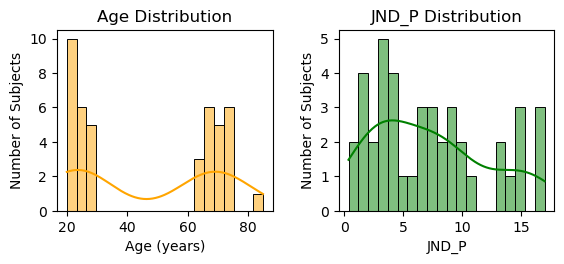

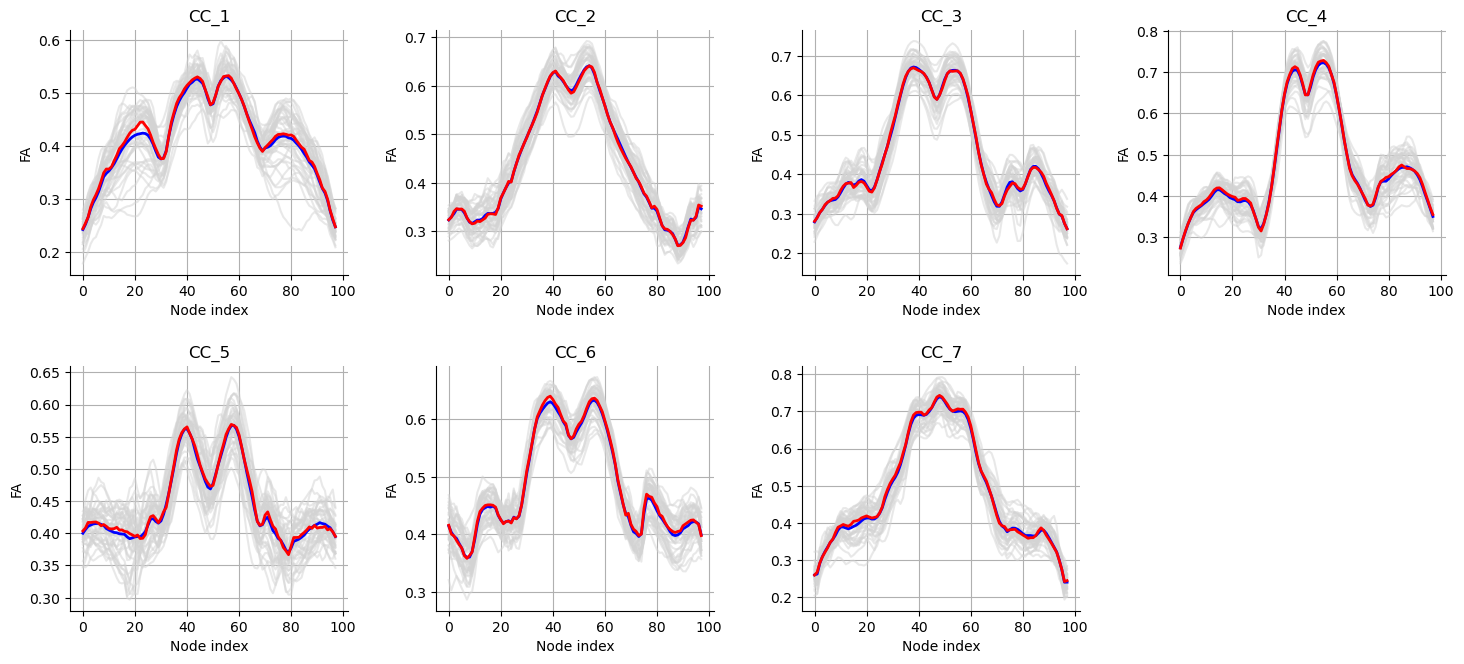

In [4]:





fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs = axs.flatten()

sns.histplot(age, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND_P Distribution')
axs[1].set_xlabel('JND_P')
axs[1].set_ylabel('Number of Subjects')
plt.tight_layout(pad=2.0)
plt.show()

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].plot(np.median(DTI_all[:,:,i], axis=0), color='red', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel('FA')
    axs[i].grid(True)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)
    
fig.delaxes(axs[7])
plt.tight_layout(pad=2.0)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, learning_curve
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, SelectFromModel
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.pipeline import Pipeline


Aging_INDICES

selection=age>0

# age=age_all[selection]
# jnd=jnd_all[selection]
# DTI=DTI_all[selection,:,:]

# scaler = RobustScaler()
# DTI_all_scaled = scaler.fit_transform(DTI.reshape(-1, DTI.shape[-1])).reshape(DTI.shape)
# DTI=DTI_all_scaled
DTI_scaled.shape

(42, 98, 7)

Feat selectio based on simple lin regression using f_regression

Feat selection based on simple linear regression using f_regression

CC 1 - Best features for JND: [76 75 77 84 74 85 83 86 82 78]
CC 1 - Best features for Age: [15 14 16 13 17 12 18 74 75 11]
CC 2 - Best features for JND: [13 87 72  7  9 73 70 69 71 86]
CC 2 - Best features for Age: [10 72  9 70 71 12 63 62 83 73]
CC 3 - Best features for JND: [14 13 22 15 23 12 21 24 67 68]
CC 3 - Best features for Age: [42 41 40 23 66 43 14 24 67 22]
CC 4 - Best features for JND: [70 69 71 57 78 56 45 77 79 54]
CC 4 - Best features for Age: [77 78 76 69 70 79  7  6 75 55]
CC 5 - Best features for JND: [74 73 15 16 58 59 42 75 60 72]
CC 5 - Best features for Age: [73 74 72 75 10 11 13 12 88  8]
CC 6 - Best features for JND: [75 84 52 86 85 87 82 83 51 88]
CC 6 - Best features for Age: [82 83 81 84 80 85 79 15 78 86]
CC 7 - Best features for JND: [41 42 53 40 38 43 54 37 39 52]
CC 7 - Best features for Age: [22 24 30 32 23  0 25 31 33 29]


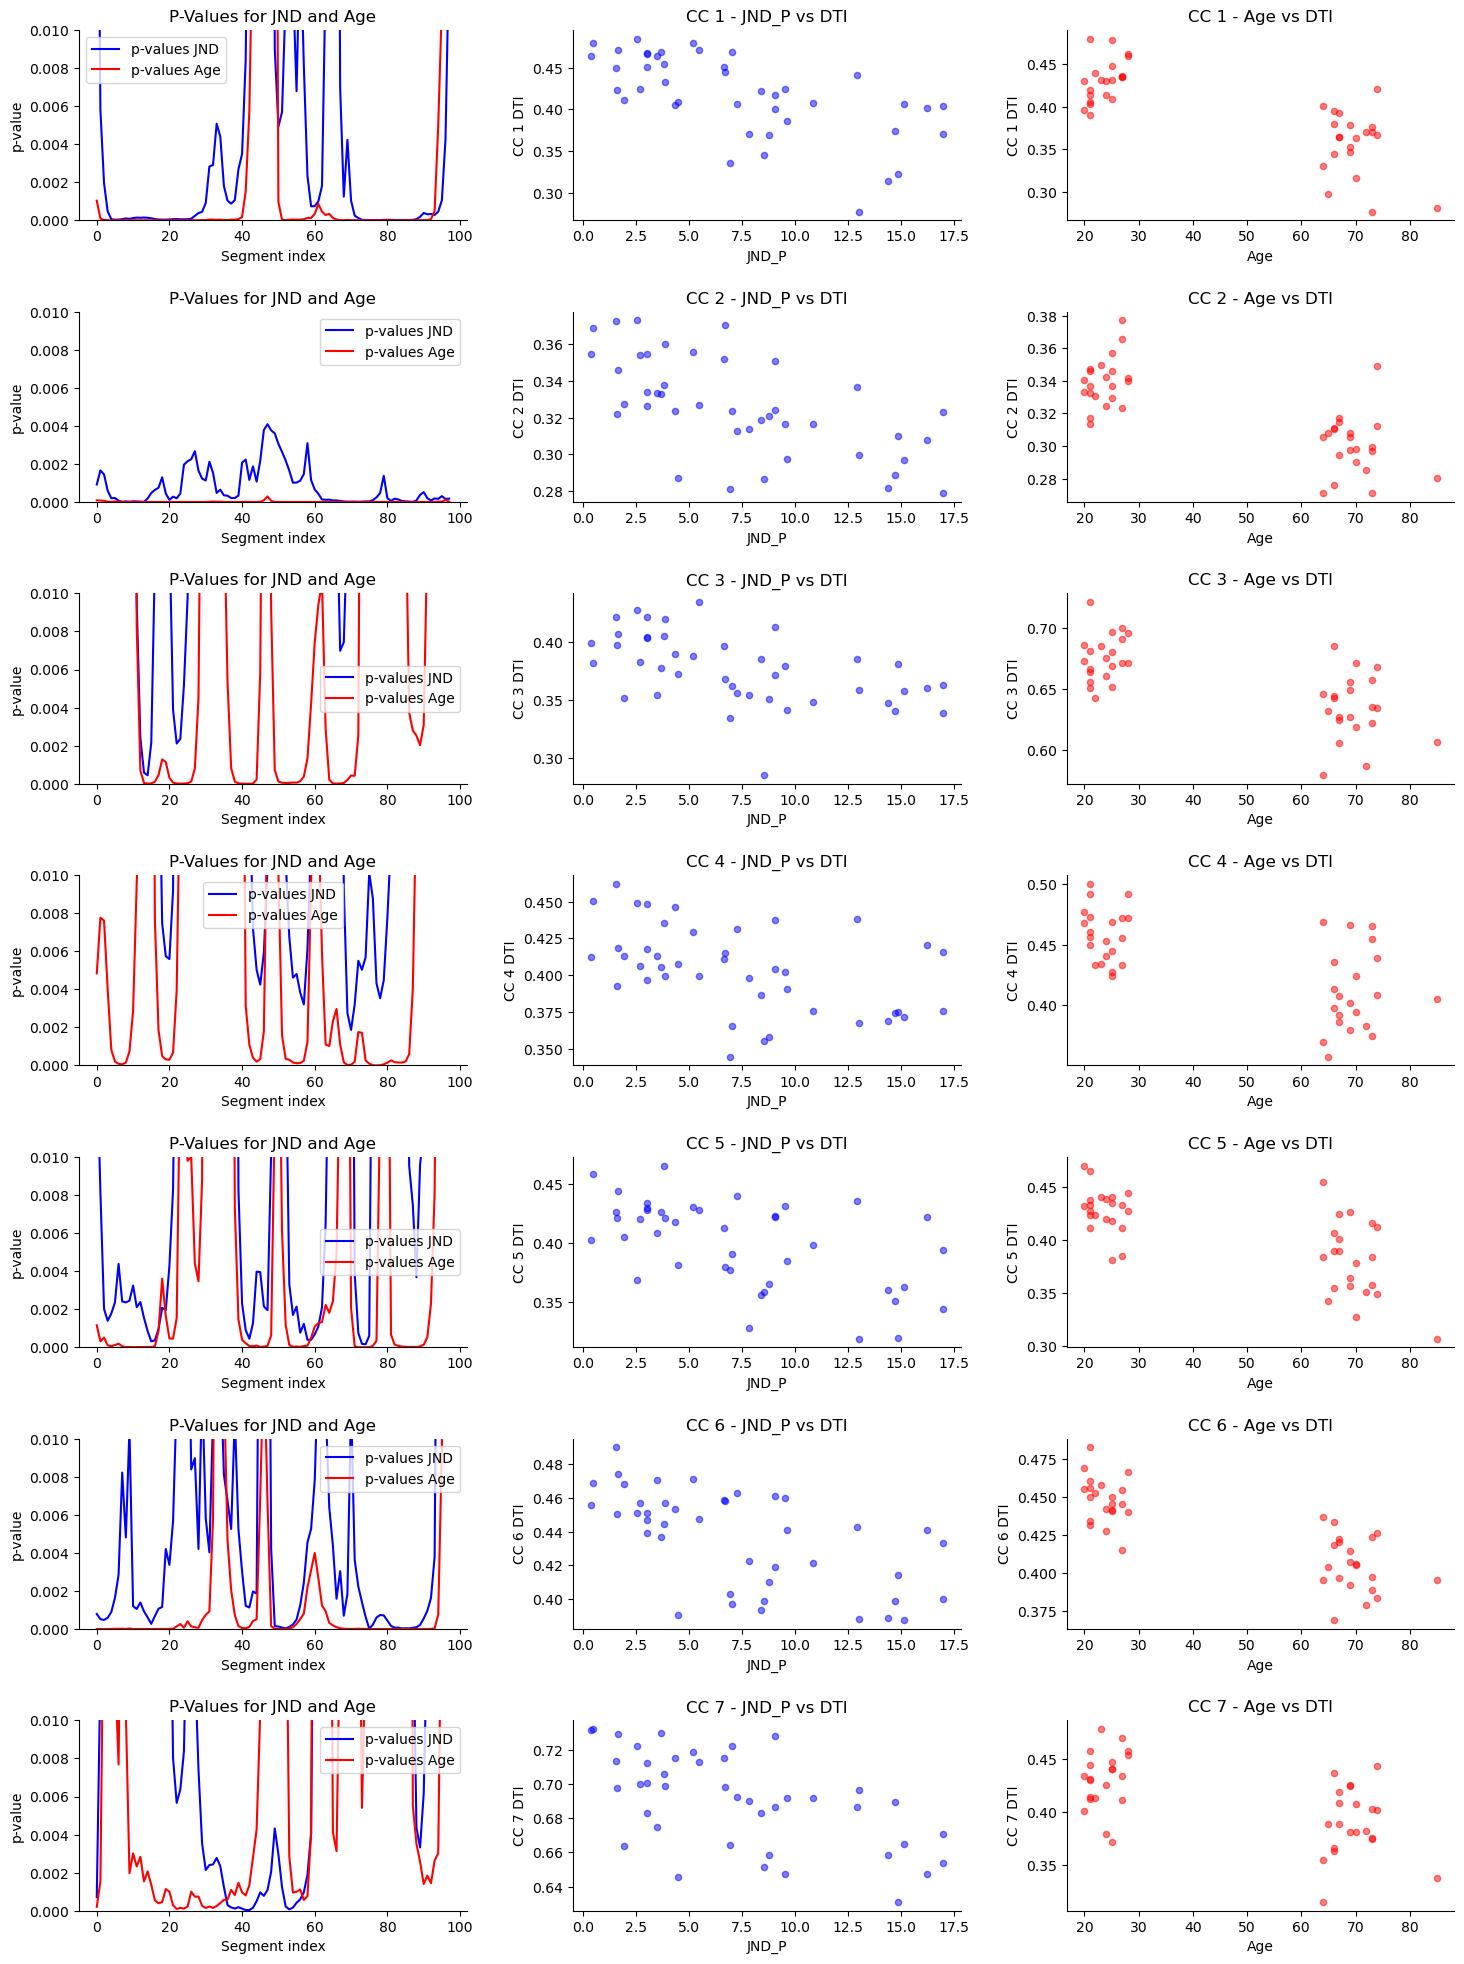

In [6]:
fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

f_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
f_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

print('Feat selection based on simple linear regression using f_regression\n')

for cc in range(1,8):
        
    f_statistic_jnd, p_values_jnd = f_regression(DTI[:,:,cc-1], jnd )
    f_statistic_age, p_values_age = f_regression(DTI[:,:,cc-1], age )

    f_reg_best_features_jnd_cc = np.argsort(p_values_jnd)[:97]
    f_reg_best_features_age_cc = np.argsort(p_values_age)[:97]
    
    print(f'CC {cc} - Best features for JND: {f_reg_best_features_jnd_cc[:10]}')
    print(f'CC {cc} - Best features for Age: {f_reg_best_features_age_cc[:10]}')

    f_reg_best_features_jnd_cc_allCC[cc-1,:]= f_reg_best_features_jnd_cc[:10]
    f_reg_best_features_age_cc_allCC[cc-1,:] = f_reg_best_features_age_cc[:10]

    axs[cc-1,0].plot(p_values_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(p_values_age, color='red', label='p-values Age')

    axs[cc-1,0].set_ylim(0, 0.01)
    axs[cc-1,0].set_xlabel('Segment index')
    axs[cc-1,0].set_ylabel('p-value')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('P-Values for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)


    featn_jnd=f_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=f_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')
    
plt.tight_layout(pad=2.0)



based on r_regression

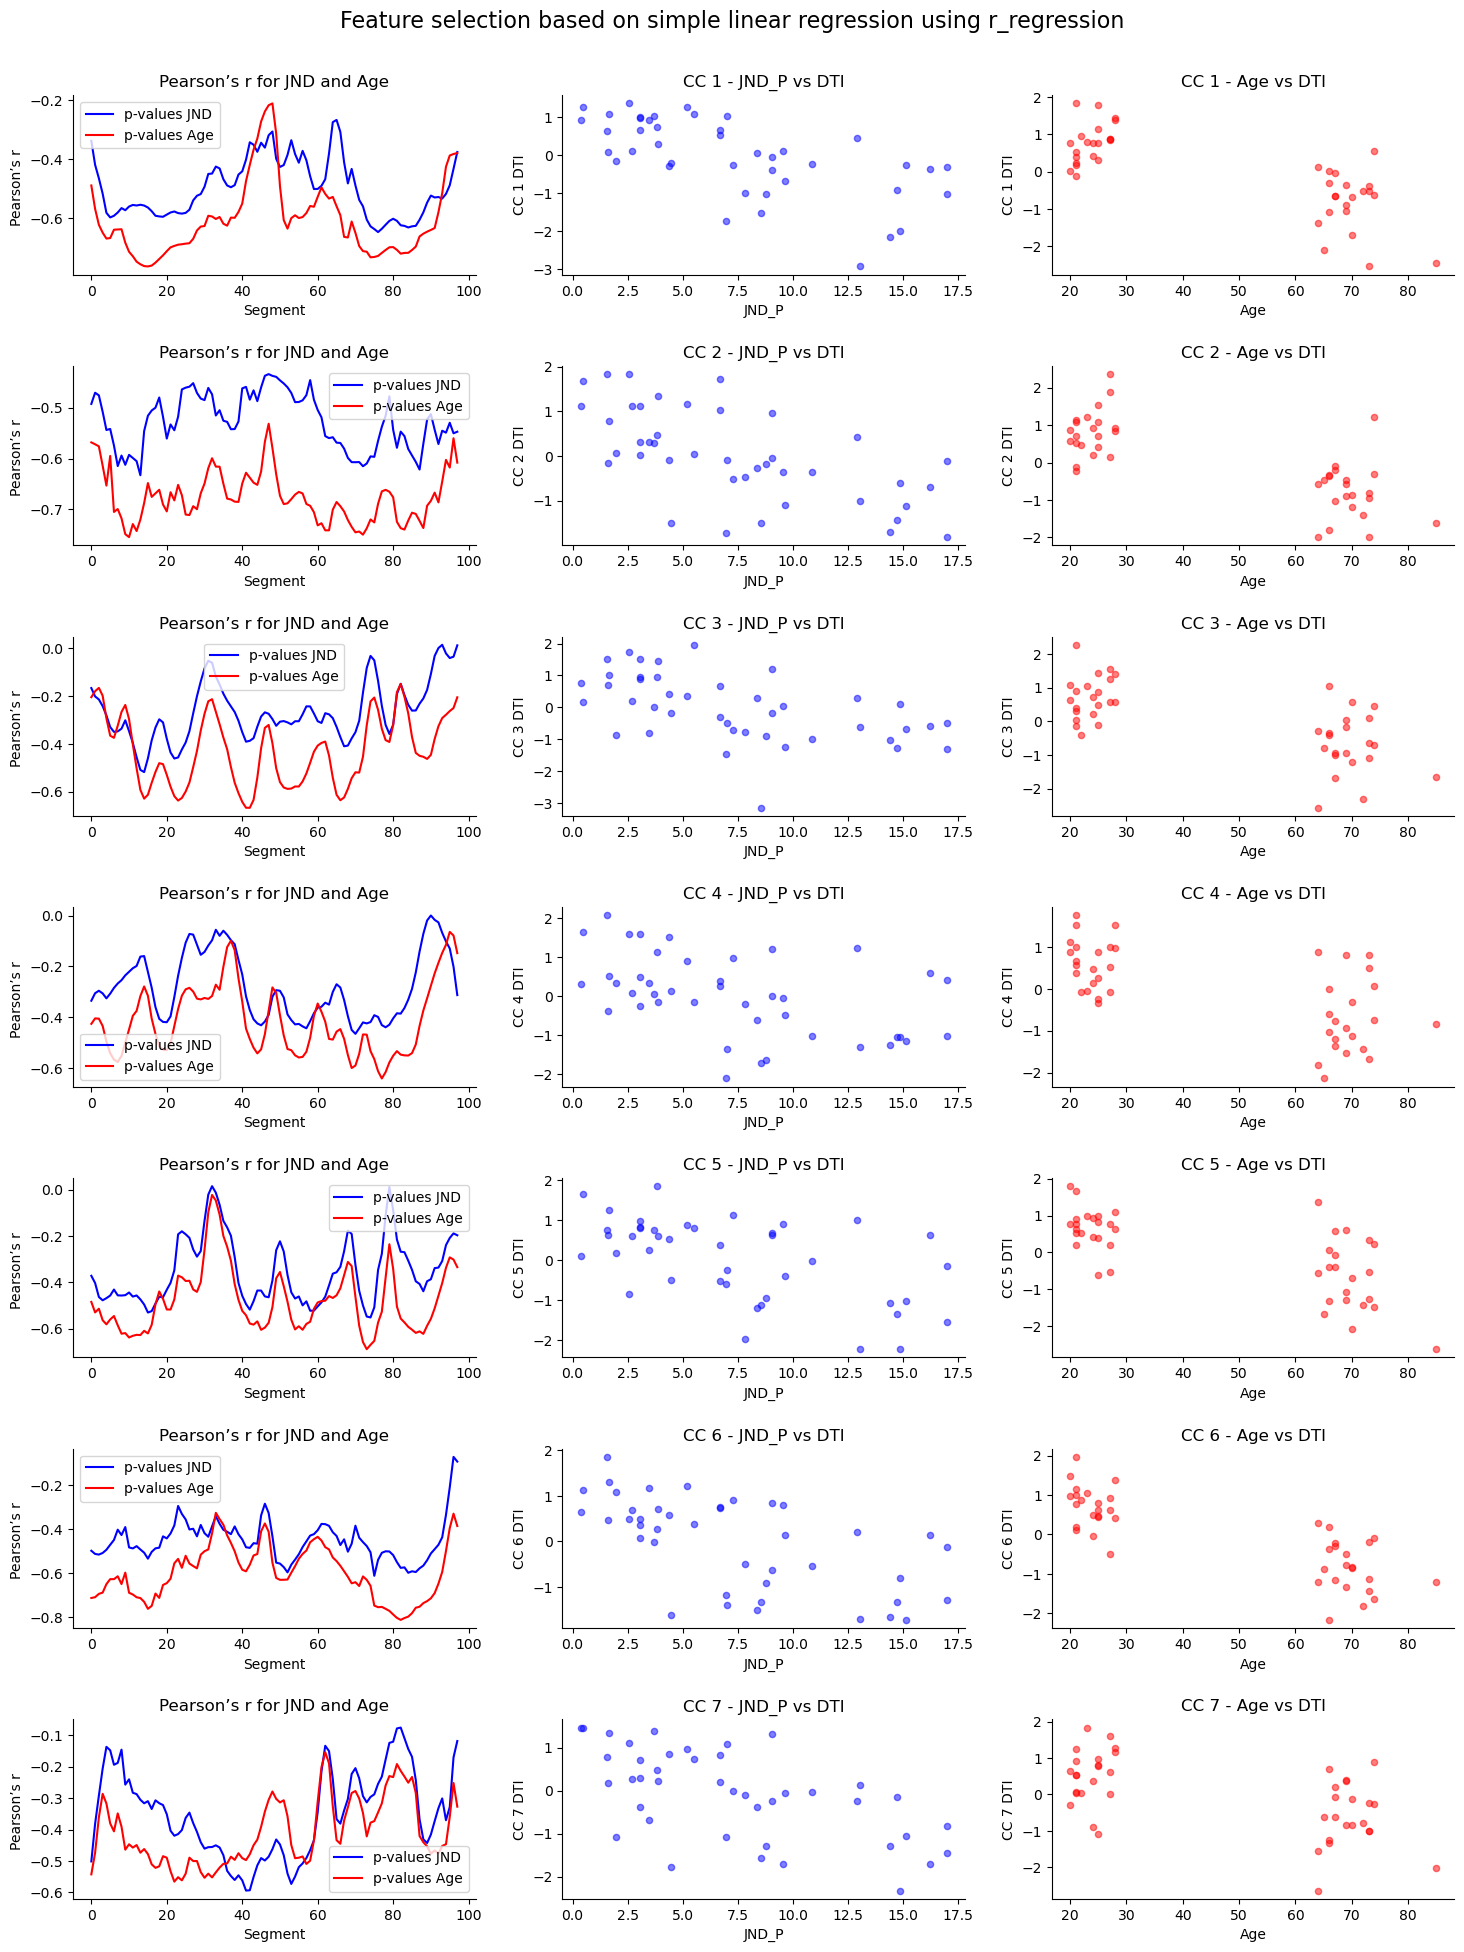

In [7]:
from sklearn.feature_selection import r_regression

####

from sklearn.feature_selection import r_regression

fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

r_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

r_reg_age_allcc = np.zeros((7,98))
for cc in range(1,8):   

    r_reg_jnd = r_regression(DTI_scaled[:,:,cc-1], jnd)
    r_reg_age = r_regression(DTI_scaled[:,:,cc-1], age)

    r_reg_age_allcc[cc-1,:] = r_reg_age
    
    r_reg_best_features_jnd_cc = np.argsort(r_reg_jnd)[:97]
    r_reg_best_features_age_cc = np.argsort(r_reg_age)[:97]

    r_reg_best_features_jnd_cc_allCC[cc-1,:]= r_reg_best_features_jnd_cc[:10]
    r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[:10]


    axs[cc-1,0].plot(r_reg_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(r_reg_age, color='red', label='p-values Age')

    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('Pearson’s r ')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('Pearson’s r for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

   
    featn_jnd=r_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=r_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI_scaled[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_scaled[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')

fig.suptitle('Feature selection based on simple linear regression using r_regression\n', fontsize=16)
    
plt.tight_layout(pad=2.0) 

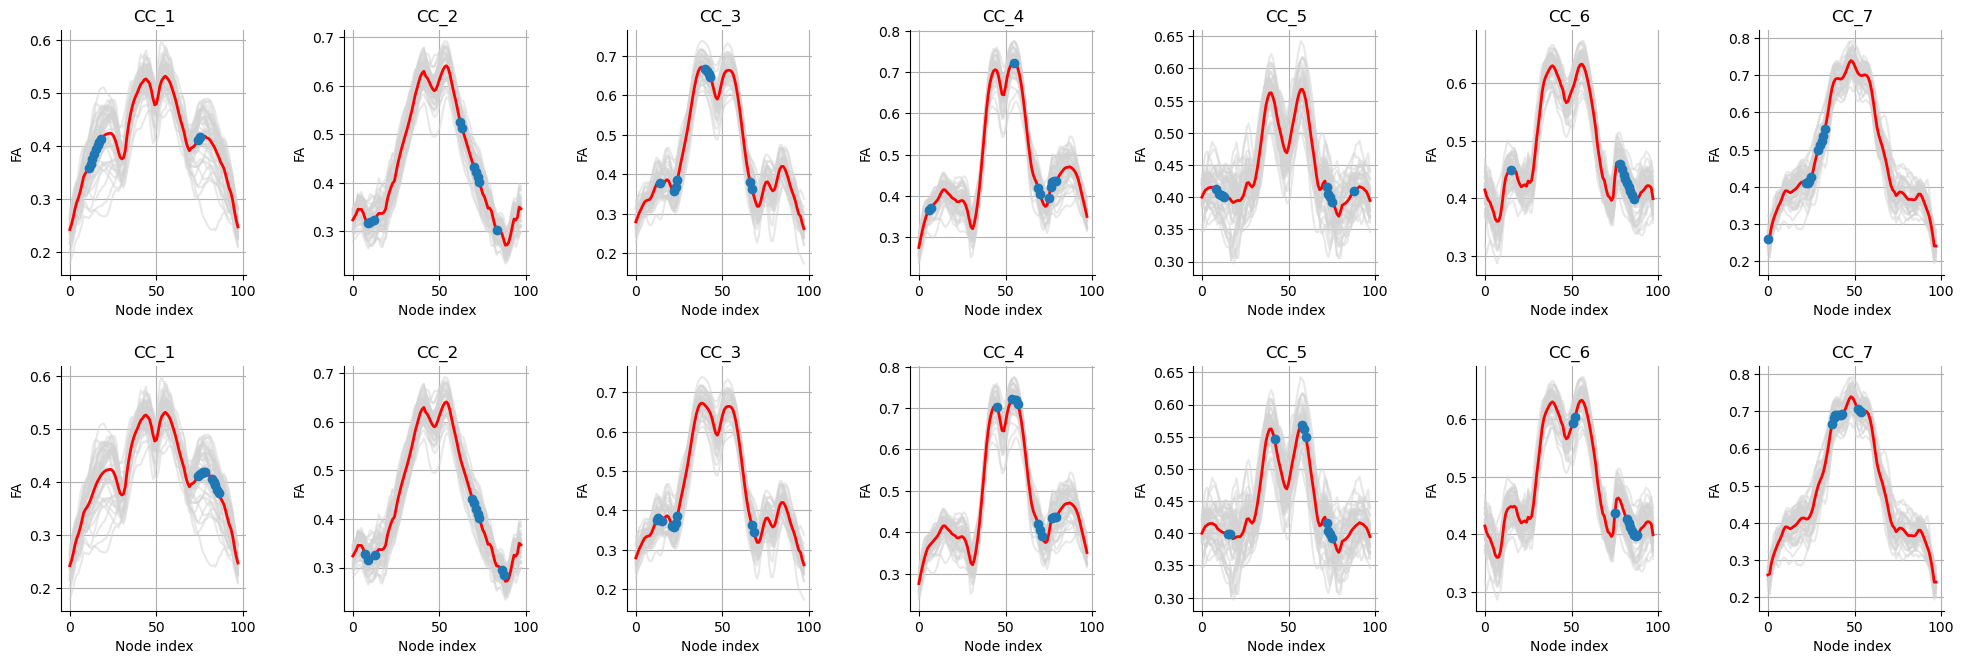

In [8]:

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=7, figsize=(20, 7))

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[0,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[0,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[0,i].plot(r_reg_best_features_age_cc_allCC[i,:], DTI[:,r_reg_best_features_age_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features Age')
    axs[0,i].set_xlabel('Node index')
    axs[0,i].set_ylabel('FA')
    axs[0,i].grid(True)
    axs[0,i].spines['top'].set_visible(False)
    axs[0,i].spines['right'].set_visible(False)
    axs[0,i].set_title(CCx)
    


for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[1,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[1,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[1,i].plot(r_reg_best_features_jnd_cc_allCC[i,:], DTI[:,r_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features JND')
    axs[1,i].set_xlabel('Node index')
    axs[1,i].set_ylabel('FA')
    axs[1,i].grid(True)
    axs[1,i].spines['top'].set_visible(False)
    axs[1,i].spines['right'].set_visible(False)
    axs[1,i].set_title(CCx)

plt.tight_layout(pad=2.0)



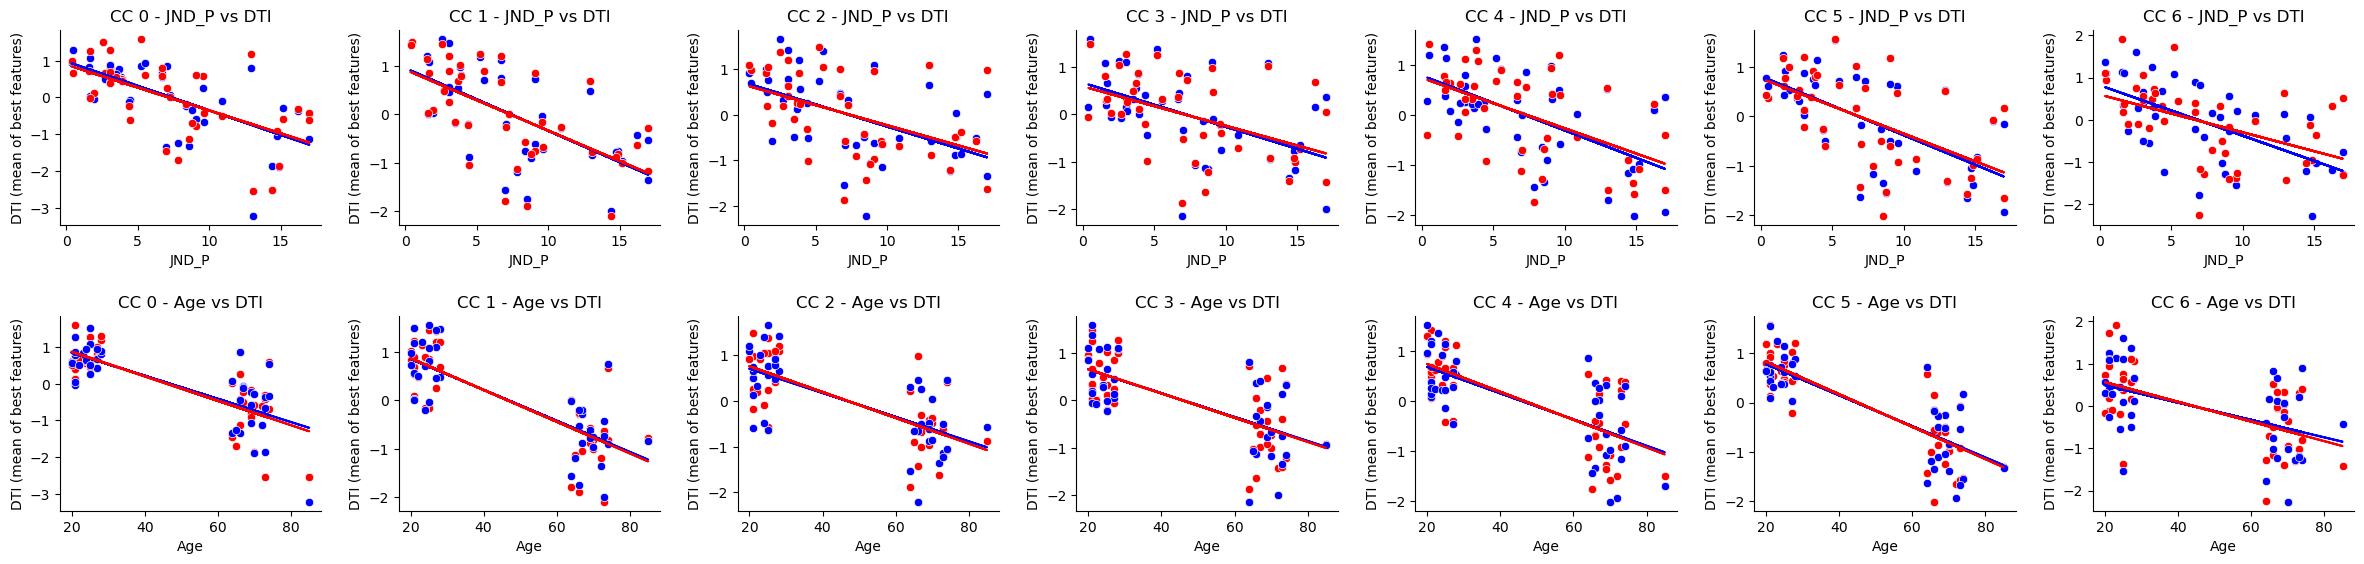

In [9]:
import statsmodels.api as sm
 

fig,axs = plt.subplots(nrows=2, ncols=7, figsize=(24,6))

for cc in range(7):

    x = sm.add_constant(jnd)
    y1=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    y2=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)
    results1 = model1.fit()
    results2 = model2.fit()
    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2


    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='blue')
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='red') 
    axs[0,cc].set_title(f'CC {cc} - JND_P vs DTI')
    axs[0,cc].spines['top'].set_visible(False)
    axs[0,cc].spines['right'].set_visible(False)
    axs[0,cc].set_xlabel('JND_P')
    axs[0,cc].set_ylabel('DTI (mean of best features)')
    # Tracer la ligne de régression
    axs[0,cc].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
    axs[0,cc].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')



    
    x = sm.add_constant(age)
    y1=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    y2=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)
    results1 = model1.fit()
    results2 = model2.fit()
    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='red')
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='blue')
    axs[1,cc].set_title(f'CC {cc} - Age vs DTI')
    axs[1,cc].spines['top'].set_visible(False)
    axs[1,cc].spines['right'].set_visible(False)
    axs[1,cc].set_xlabel('Age')
    axs[1,cc].set_ylabel('DTI (mean of best features)')
    axs[1,cc].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
    axs[1,cc].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')

plt.tight_layout(pad=2.0)



       


Regression prediction test on cc 7 best feat

[22 24 30 32 23  0 25 31 33 29]
[41 42 53 40 38 43 54 37 39 52]
Mean MSE for JND: 25.2422 ± 9.4792
Mean MSE for Age: 25.0350 ± 9.5916
P-value from independent t-test: 0.8786
Mean R² for JND: -0.2273 ± 0.6336
Mean R² for Age: -0.2097 ± 0.6299
P-value from independent t-test: 0.8449
Mean MAE for JND: 4.1370 ± 0.8599
Mean MAE for Age: 4.0635 ±   0.8706
P-value from independent t-test: 0.5508


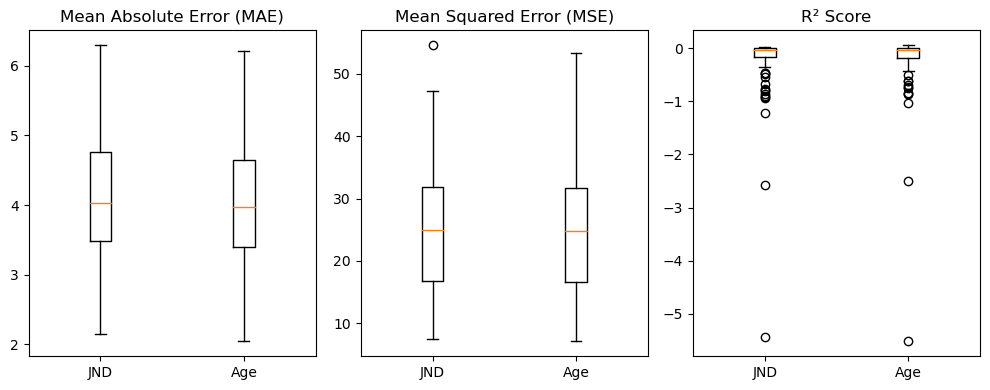

In [10]:
cc=6
print(r_reg_best_features_age_cc_allCC[cc])
print(r_reg_best_features_jnd_cc_allCC[cc])

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_rel as t_test_rel, ttest_ind as t_test_ind

mae_jnd_rd = []
mae_age_rd = []
mse_jnd_rd = []
mse_age_rd = []
r2_jnd_rd = []
r2_age_rd = []

for rd in range(100):

    X_train,X_test,y_train,y_test=train_test_split(DTI[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc], jnd, test_size=0.2, random_state=rd)
    regr=svm.SVR(kernel='linear')
    regr.fit(X_train, y_train)
    y_pred = regr.predict(X_test)
    regr.score(X_test, y_test)

    mae_jnd_rd.append(mean_absolute_error(y_test, y_pred))
    mse_jnd_rd.append(mean_squared_error(y_test, y_pred))
    r2_jnd_rd.append(r2_score(y_test, y_pred))

    X_train,X_test,y_train,y_test=train_test_split(DTI[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc], jnd, test_size=0.2, random_state=rd)
    regr=svm.SVR(kernel='linear')
    regr.fit(X_train, y_train)
    y_pred = regr.predict(X_test)
    regr.score(X_test, y_test)
  
    mae_age_rd.append(mean_absolute_error(y_test, y_pred))
    mse_age_rd.append(mean_squared_error(y_test, y_pred))
    r2_age_rd.append(r2_score(y_test, y_pred))




fig,ax=plt.subplots(nrows=1, ncols=3,figsize=(10,4))
ax[0].boxplot([mae_jnd_rd, mae_age_rd], labels=['JND', 'Age'])
ax[0].set_title('Mean Absolute Error (MAE)')
ax[1].boxplot([mse_jnd_rd, mse_age_rd], labels=['JND', 'Age'])
ax[1].set_title('Mean Squared Error (MSE)')
ax[2].boxplot([r2_jnd_rd, r2_age_rd], labels=['JND', 'Age'])
ax[2].set_title('R² Score')
plt.tight_layout()

t,pvalue=t_test_ind(mse_jnd_rd, mse_age_rd)
print(f'Mean MSE for JND: {np.mean(mse_jnd_rd):.4f} ± {np.std(mse_jnd_rd):.4f}')
print(f'Mean MSE for Age: {np.mean(mse_age_rd):.4f} ± {np.std(mse_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

t,pvalue=t_test_ind(r2_jnd_rd, r2_age_rd)
print(f'Mean R² for JND: {np.mean(r2_jnd_rd):.4f} ± {np.std(r2_jnd_rd):.4f}')
print(f'Mean R² for Age: {np.mean(r2_age_rd):.4f} ± {np.std(r2_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

t,pvalue=t_test_ind(mae_jnd_rd, mae_age_rd)
print(f'Mean MAE for JND: {np.mean(mae_jnd_rd):.4f} ± {np.std(mae_jnd_rd):.4f}')
print(f'Mean MAE for Age: {np.mean(mae_age_rd):.4f} ±   {np.std(mae_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

In [11]:


DTI_JND=pd.DataFrame([])
DTI_AGE=pd.DataFrame([])
for cc in range(1,8):
    DTI_JND_tmp=pd.DataFrame(DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc-1],cc-1])
    DTI_JND_tmp.columns = [f'CC{cc}_{idx}' for idx in r_reg_best_features_jnd_cc_allCC[cc-1]]
    DTI_JND=pd.concat([DTI_JND, DTI_JND_tmp], axis=1)

    DTI_AGE_tmp=pd.DataFrame(DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc-1],cc-1])
    DTI_AGE_tmp.columns = [f'CC{cc}_{idx}' for idx in r_reg_best_features_age_cc_allCC[cc-1]]
    DTI_AGE=pd.concat([DTI_AGE, DTI_AGE_tmp], axis=1)




DTI_JND.describe()


,CC1_76,CC1_75,CC1_77,CC1_84,CC1_74,CC1_85,CC1_83,CC1_86,CC1_82,CC1_78,...,CC7_41,CC7_42,CC7_53,CC7_40,CC7_38,CC7_43,CC7_54,CC7_37,CC7_39,CC7_52
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,...,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,-0.029588,-0.019089,-0.031368,0.033262,-0.008575,0.033558,0.031827,0.024973,0.020988,-0.026907,...,-0.085670,-0.082329,-0.044088,-0.071927,-0.048580,-0.050251,-0.050147,-0.047492,-0.055989,-0.029046
std,1.023542,1.026540,1.021915,1.041731,1.033680,1.048222,1.036284,1.049296,1.036993,1.025329,...,1.033986,1.033503,1.041356,1.040175,1.032300,1.053566,1.036860,1.030258,1.039031,1.060409
min,-2.922354,-2.646431,-3.098661,-3.691987,-2.482866,-3.475097,-3.653256,-3.177759,-3.669906,-3.286597,...,-2.326982,-2.454563,-2.494331,-2.104822,-2.100162,-2.496502,-2.729615,-2.104675,-2.101420,-2.700300
25%,-0.372732,-0.374217,-0.404212,-0.595691,-0.450522,-0.609922,-0.570834,-0.574150,-0.545244,-0.475573,...,-1.002908,-0.728174,-0.671742,-0.972973,-0.882304,-0.604952,-0.770805,-0.847277,-0.877436,-0.799574
50%,0.072936,0.120216,0.061958,0.268253,0.201820,0.298670,0.224293,0.177309,0.152938,0.052854,...,-0.026821,-0.080076,-0.103852,0.125866,0.194333,-0.117548,0.094197,0.189638,0.145470,-0.088249
75%,0.868494,0.811022,0.789614,0.823345,0.715079,0.842587,0.753029,0.938380,0.824970,0.732204,...,0.769165,0.715632,0.698416,0.782357,0.683992,0.736880,0.835288,0.712831,0.751020,0.769445
max,1.357095,1.413808,1.326143,1.676764,1.515941,1.577227,1.751379,1.555624,1.700549,1.446910,...,1.470812,1.963718,2.125678,1.603749,1.566164,2.349324,1.614007,1.730981,1.597754,2.261473


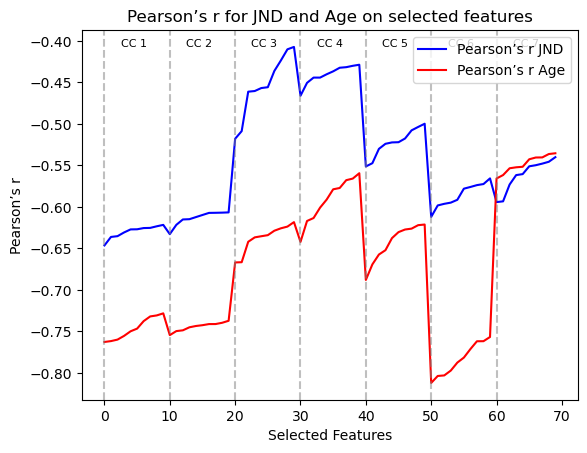

In [12]:
cc=1
r_reg_jnd70 = r_regression(DTI_JND, jnd)
r_reg_age70 = r_regression(DTI_AGE, age)


plt.plot(r_reg_jnd70, color='blue', label='Pearson’s r JND')
plt.plot(r_reg_age70, color='red', label='Pearson’s r Age')
plt.xlabel('Selected Features')
plt.ylabel('Pearson’s r')
plt.title('Pearson’s r for JND and Age on selected features')
plt.legend()

for i in range(7):
    plt.axvline(x=i*10, color='gray', linestyle='--', alpha=0.5)
    plt.text(i*10 + 2.5, max(max(r_reg_jnd70), max(r_reg_age70)), f'CC {i+1}', color='black', fontsize=8)


<Axes: >

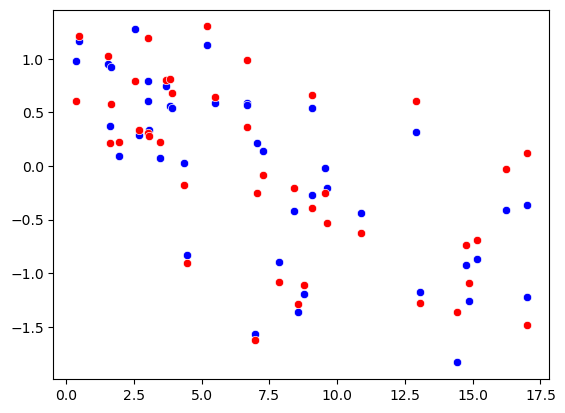

In [13]:
from sklearn.feature_selection import SequentialFeatureSelector

X=DTI_JND
y=jnd
sfs = SequentialFeatureSelector(estimator=svm.SVR(kernel='linear'), n_features_to_select=10, direction='forward')
sfs.fit(X, y)
X10=sfs.transform(X)

sns.scatterplot(x=y, y=X10.mean(axis=1), color='blue')


X=DTI_AGE
y=jnd
sfs = SequentialFeatureSelector(estimator=svm.SVR(kernel='linear'), n_features_to_select=10, direction='forward')
sfs.fit(X, y)
X10=sfs.transform(X)

sns.scatterplot(x=y, y=X10.mean(axis=1), color='red')


In [14]:
Aging_INDICES['JND_group3'] = pd.qcut(Aging_INDICES['JND_P'], q=3, labels=[0,1,2])
Aging_INDICES['JND_group3']

0     2
1     1
2     2
3     0
4     0
5     1
6     2
7     1
8     0
9     0
10    0
11    0
12    2
13    2
14    2
15    1
16    0
17    0
18    2
19    1
20    0
21    2
22    1
23    0
24    0
25    2
26    0
27    2
28    1
29    0
30    1
31    1
32    0
33    1
34    1
35    1
36    2
37    1
38    2
39    2
40    2
41    1
Name: JND_group3, dtype: category
Categories (3, int64): [0 < 1 < 2]

JND_group
0    21
1    21
Name: count, dtype: int64
T-test JND group: t=6.2753, p=0.0000
T-test JND group: t=6.3284, p=0.0000
T-test Age group: t=7.6918, p=0.0000
T-test Age group: t=9.1087, p=0.0000


(42, 70)

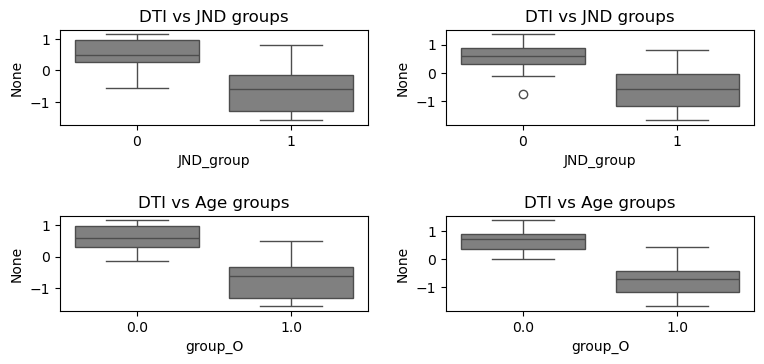

In [15]:


fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(8,4))
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['JND_group'], color='grey', ax=axs[0,0])
axs[0,0].set_title('DTI vs JND groups')

sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['JND_group'], color='grey', ax=axs[0,1])
axs[0,1].set_title('DTI vs JND groups')
print(Aging_INDICES['JND_group'].value_counts())
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,0])
axs[1,0].set_title('DTI vs Age groups')
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,1])
axs[1,1].set_title('DTI vs Age groups')
plt.tight_layout(pad=2.0)

t,pval=t_test_ind(DTI_JND.mean(axis=1)[Aging_INDICES['JND_group']==0], DTI_JND.mean(axis=1)[Aging_INDICES['JND_group']==1])
print(f'T-test JND group: t={t:.4f}, p={pval:.4f}')
t,pval=t_test_ind(DTI_AGE.mean(axis=1)[Aging_INDICES['JND_group']==0], DTI_AGE.mean(axis=1)[Aging_INDICES['JND_group']==1])
print(f'T-test JND group: t={t:.4f}, p={pval:.4f}')
t,pval=t_test_ind(DTI_JND.mean(axis=1)[Aging_INDICES['group_O']==0], DTI_JND.mean(axis=1)[Aging_INDICES['group_O']==1])
print(f'T-test Age group: t={t:.4f}, p={pval:.4f}')
t,pval=t_test_ind(DTI_AGE.mean(axis=1)[Aging_INDICES['group_O']==0], DTI_AGE.mean(axis=1)[Aging_INDICES['group_O']==1])
print(f'T-test Age group: t={t:.4f}, p={pval:.4f}')
DTI_JND.shape

JND_group3
0    14
1    14
2    14
Name: count, dtype: int64


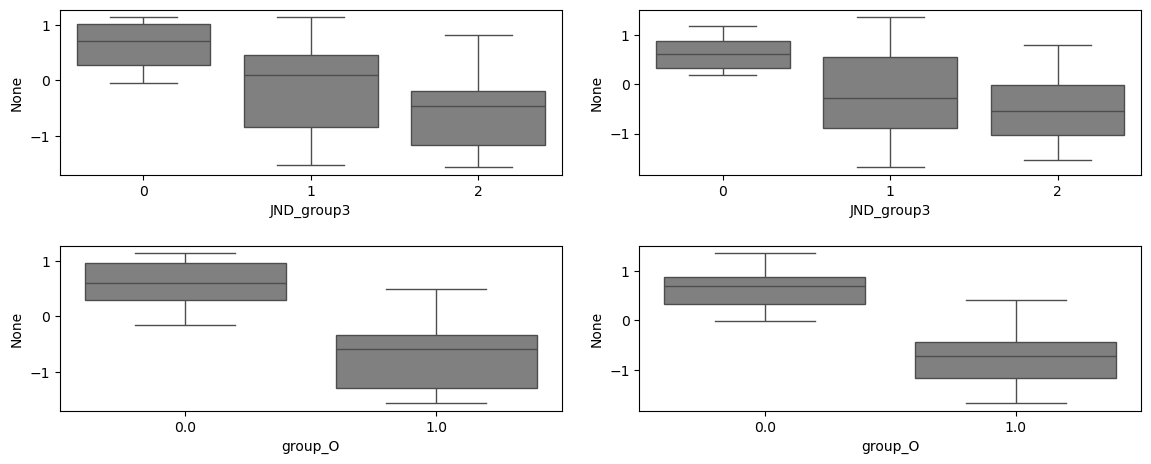

In [16]:


fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['JND_group3'], color='grey', ax=axs[0,0])
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['JND_group3'], color='grey', ax=axs[0,1])
print(Aging_INDICES['JND_group3'].value_counts())
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,0])
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,1])
plt.tight_layout(pad=2.0)



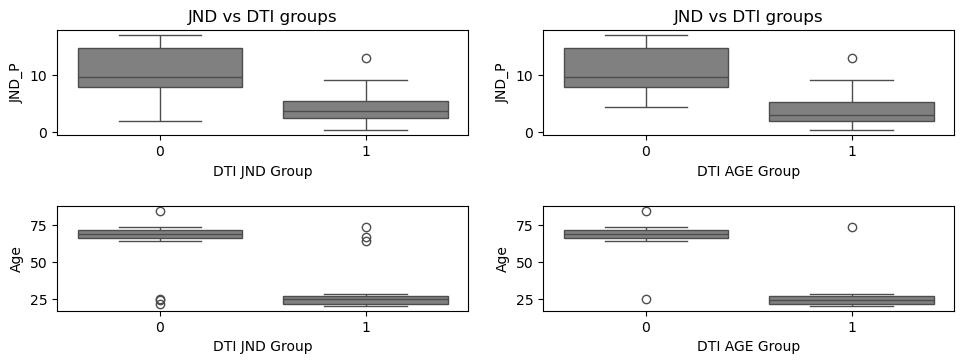

In [17]:
DTI_3g_JND = pd.qcut(DTI_JND.mean(axis=1), q=2, labels=[0,1])
DTI_3g_AGE = pd.qcut(DTI_AGE.mean(axis=1), q=2, labels=[0,1])

fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(10,4))

sns.boxplot(y=jnd,x=DTI_3g_JND,color='grey', ax=axs[0,0])
sns.boxplot(y=jnd,x=DTI_3g_AGE,color='grey', ax=axs[0,1])
axs[0,0].set_xlabel('DTI JND Group')
axs[0,0].set_ylabel('JND_P')
axs[0,1].set_xlabel('DTI AGE Group')
axs[0,1].set_ylabel('JND_P')

sns.boxplot(y=age,x=DTI_3g_JND,color='grey', ax=axs[1,0])
sns.boxplot(y=age,x=DTI_3g_AGE,color='grey', ax=axs[1,1])
axs[1,0].set_xlabel('DTI JND Group')
axs[1,0].set_ylabel('Age')
axs[1,1].set_xlabel('DTI AGE Group')
axs[1,1].set_ylabel('Age')

axs[0,0].set_title('JND vs DTI groups')
axs[0,1].set_title('JND vs DTI groups')
plt.tight_layout(pad=2.0)



Text(0.5, 1.0, 'JND vs DTI groups')

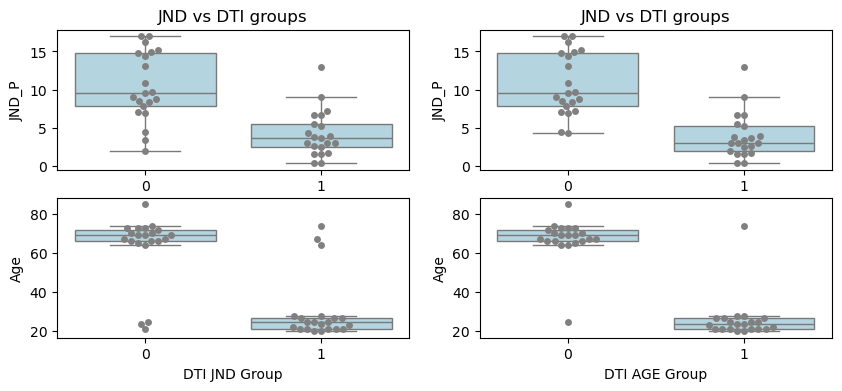

In [18]:
fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(10,4))

sns.swarmplot(y=jnd,x=DTI_3g_JND,color='grey', ax=axs[0,0])
sns.boxplot(y=jnd,x=DTI_3g_JND,color='lightblue', ax=axs[0,0], showfliers=False)

sns.swarmplot(y=jnd,x=DTI_3g_AGE,color='grey', ax=axs[0,1])
sns.boxplot(y=jnd,x=DTI_3g_AGE,color='lightblue', ax=axs[0,1], showfliers=False)
axs[0,0].set_xlabel('DTI JND Group')
axs[0,0].set_ylabel('JND_P')
axs[0,1].set_xlabel('DTI AGE Group')
axs[0,1].set_ylabel('JND_P')
sns.swarmplot(y=age,x=DTI_3g_JND,color='grey', ax=axs[1,0])
sns.boxplot(y=age,x=DTI_3g_JND,color='lightblue', ax=axs[1,0], showfliers=False)
sns.swarmplot(y=age,x=DTI_3g_AGE,color='grey', ax=axs[1,1])
sns.boxplot(y=age,x=DTI_3g_AGE,color='lightblue', ax=axs[1,1], showfliers=False)
axs[1,0].set_xlabel('DTI JND Group')
axs[1,0].set_ylabel('Age')
axs[1,1].set_xlabel('DTI AGE Group')
axs[1,1].set_ylabel('Age')
axs[0,0].set_title('JND vs DTI groups')
axs[0,1].set_title('JND vs DTI groups')


CC 1 - ROC Curve Analysis

Mean AUC for Age: 0.9488 ± 0.0385
Mean AUC for JND: 0.8965 ± 0.0594
P-value from independent t-test: 0.0000
CC 2 - ROC Curve Analysis

Mean AUC for Age: 0.9633 ± 0.0269
Mean AUC for JND: 0.9093 ± 0.0474
P-value from independent t-test: 0.0000
CC 3 - ROC Curve Analysis

Mean AUC for Age: 0.8815 ± 0.0553
Mean AUC for JND: 0.8558 ± 0.0620
P-value from independent t-test: 0.0023
CC 4 - ROC Curve Analysis

Mean AUC for Age: 0.8607 ± 0.0585
Mean AUC for JND: 0.7806 ± 0.0745
P-value from independent t-test: 0.0000
CC 5 - ROC Curve Analysis

Mean AUC for Age: 0.8681 ± 0.0583
Mean AUC for JND: 0.7710 ± 0.0778
P-value from independent t-test: 0.0000
CC 6 - ROC Curve Analysis

Mean AUC for Age: 0.9623 ± 0.0299
Mean AUC for JND: 0.8586 ± 0.0589
P-value from independent t-test: 0.0000
CC 7 - ROC Curve Analysis

Mean AUC for Age: 0.7494 ± 0.0740
Mean AUC for JND: 0.8134 ± 0.0773
P-value from independent t-test: 0.0000


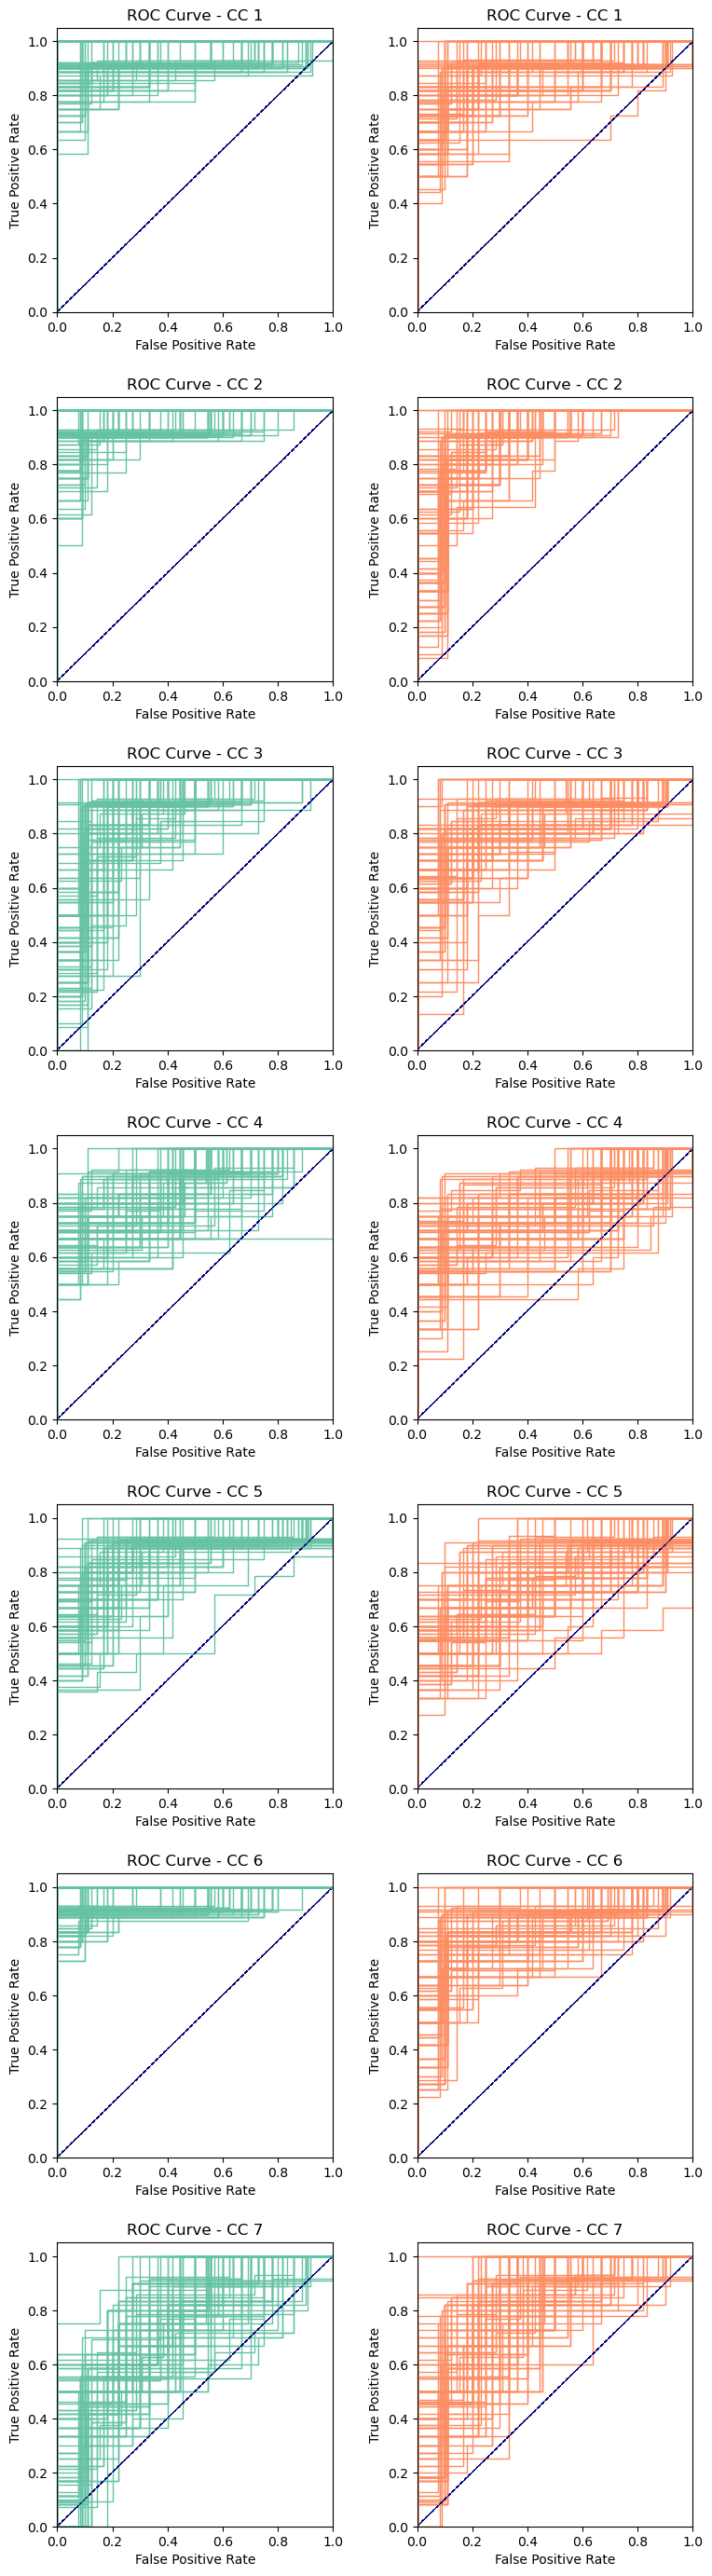

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score





colors = sns.color_palette('Set2')
first_color = colors[0]
second_color = colors[1]


roc_auc_all_cc=[[] for _ in range(7)]

fig, axs = plt.subplots(nrows=7, ncols=2, figsize=(8, 28))
for cc in range(7):
    print(f'CC {cc+1} - ROC Curve Analysis\n')
    
    X=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc]

    target_var=  ['Age', 'JND']
    roc_auc_all = [[] for _ in target_var]


    for i, target in enumerate(target_var):
        if target == 'Age':
            y=age_grouped

        elif target == 'JND':
            y=jnd_grouped

        for seed in range(100):
            # Diviser les données en ensembles d'entraînement et de test
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)

            # Entraîner un modèle de régression logistique
            model = LogisticRegression()
            model.fit(X_train, y_train)

            # Prédire les probabilités
            y_scores = model.predict_proba(X_test)[:, 1]

            # Calculer les taux de vrais positifs et de faux positifs
            fpr, tpr, thresholds = roc_curve(y_test, y_scores)

            # Calculer l'aire sous la courbe ROC (AUC)
            roc_auc = auc(fpr, tpr)

            # Tracer la courbe ROC
            axs[cc,i].plot(fpr, tpr, color=colors[i], lw=1)
            axs[cc,i].plot([0, 1], [0, 1], color='navy', lw=0.5, linestyle=':')
            axs[cc,i].set_xlim([0.0, 1.0])
            axs[cc,i].set_ylim([0.0, 1.05])
            axs[cc,i].set_xlabel('False Positive Rate')
            axs[cc,i].set_ylabel('True Positive Rate')
            axs[cc,i].set_title( 'ROC Curve - CC {}'.format(cc+1))
            # axs[cc].legend(loc="lower right")

            # Calculer l'AUC
            roc_auc = roc_auc_score(y_test, y_scores)
            roc_auc_all[i].append(roc_auc)
            # print(f'AUC: {roc_auc:.2f}')

    roc_auc_all_cc[cc] = roc_auc_all


    t,pvalue=t_test_ind(roc_auc_all[0], roc_auc_all[1])
    print(f'Mean AUC for Age: {np.mean(roc_auc_all[0]):.4f} ± {np.std(roc_auc_all[0]):.4f}')
    print(f'Mean AUC for JND: {np.mean(roc_auc_all[1]):.4f} ± {np.std(roc_auc_all[1]):.4f}')
    print(f'P-value from independent t-test: {pvalue:.4f}')


plt.tight_layout(pad=2.0)

CC 1 - Mean AUC for Age: 0.9488 ± 0.0385
CC 2 - Mean AUC for Age: 0.9633 ± 0.0269
CC 3 - Mean AUC for Age: 0.8815 ± 0.0553
CC 4 - Mean AUC for Age: 0.8607 ± 0.0585
CC 5 - Mean AUC for Age: 0.8681 ± 0.0583
CC 6 - Mean AUC for Age: 0.9623 ± 0.0299
CC 7 - Mean AUC for Age: 0.7494 ± 0.0740


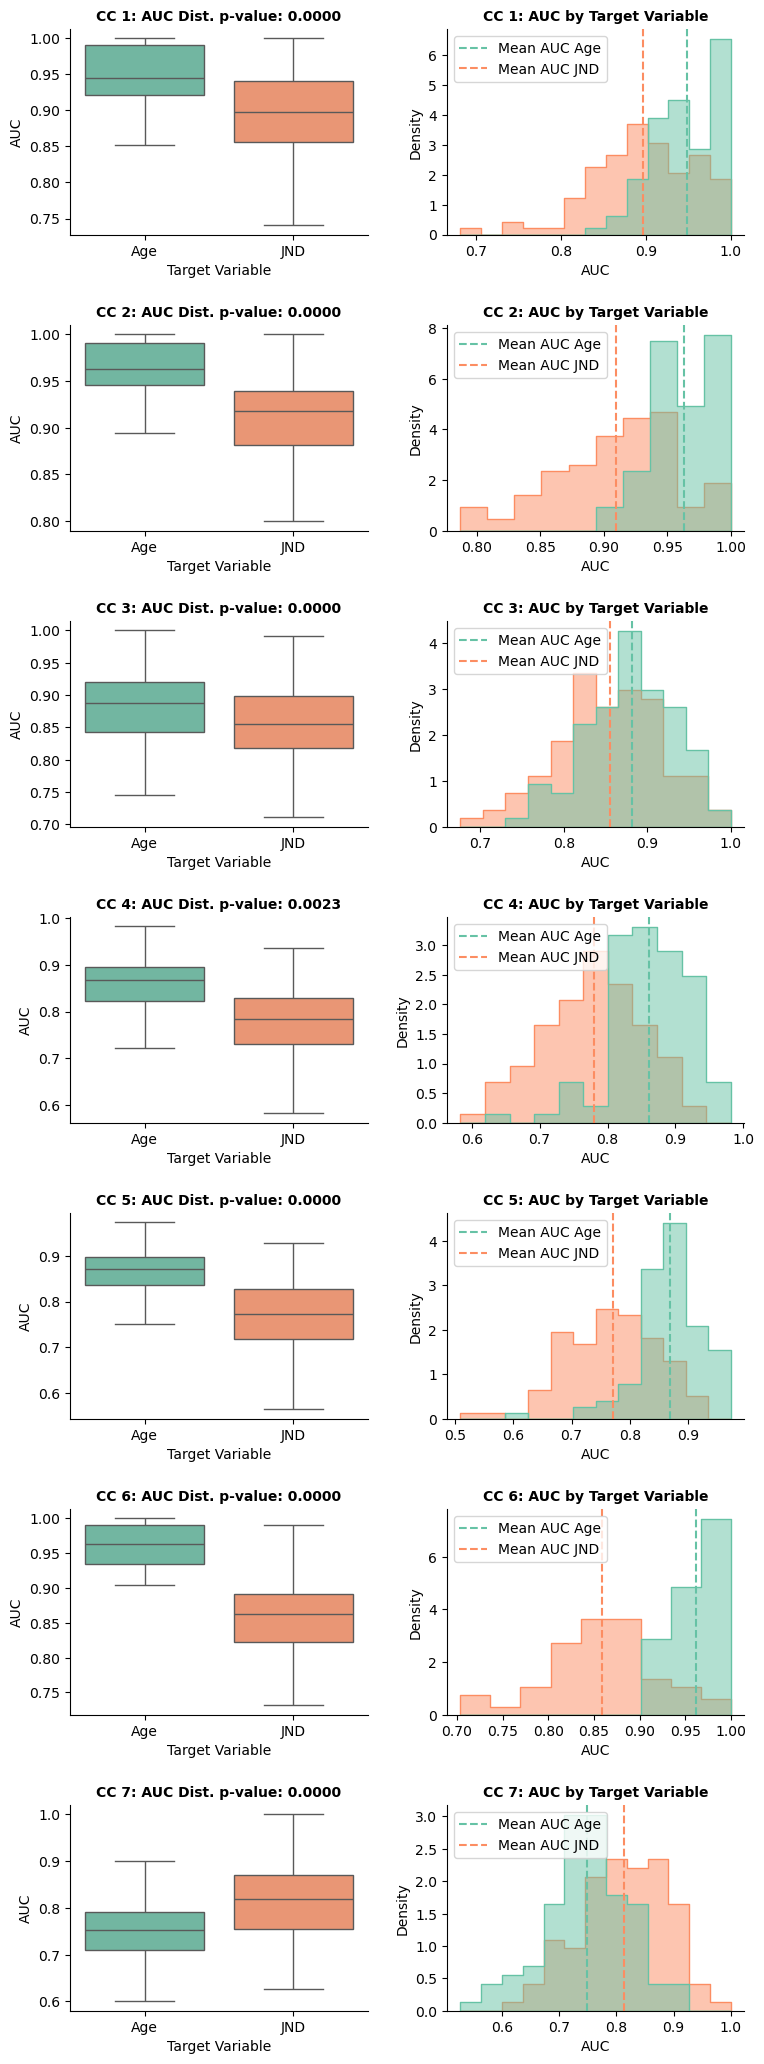

In [24]:


fig,axs = plt.subplots(nrows=7, ncols=2, figsize=(8,21))
for cc in range(7):
    df=pd.DataFrame({'AUC': roc_auc_all_cc[cc][0] + roc_auc_all_cc[cc][1], 'Target': ['Age']*len(roc_auc_all_cc[cc][0]) + ['JND']*len(roc_auc_all_cc[cc][1])})

    sns.boxplot(x='Target', y='AUC', data=df, ax=axs[cc,0], palette='Set2',showfliers=False)
    axs[cc,0].set_title(f'CC {cc+1}: AUC Dist. p-value: {pvalue:.4f}', fontsize=10,fontweight='bold')
    axs[cc,0].set_xlabel('Target Variable')
    axs[cc,0].set_ylabel('AUC')
    axs[cc,0].spines['top'].set_visible(False)
    axs[cc,0].spines['right'].set_visible(False)   
    t,pvalue=t_test_ind(roc_auc_all_cc[cc][0], roc_auc_all_cc[cc][1])
    print(f'CC {cc+1} - Mean AUC for Age: {np.mean(roc_auc_all_cc[cc][0]):.4f} ± {np.std(roc_auc_all_cc[cc][0]):.4f}')

    sns.histplot(data=df, x='AUC', hue='Target', element='step', stat='density', common_norm=True, ax=axs[cc,1], palette='Set2', alpha=0.5,legend=False)
    axs[cc,1].set_xlabel('AUC')
    axs[cc,1].set_title(f'CC {cc+1}: AUC by Target Variable', fontsize=10,fontweight='bold')
    axs[cc,1].spines['top'].set_visible(False)
    axs[cc,1].spines['right'].set_visible(False)
    axs[cc,1].axvline(x=np.mean(roc_auc_all_cc[cc][0]), color=first_color, linestyle='--', label='Mean AUC Age')
    axs[cc,1].axvline(x=np.mean(roc_auc_all_cc[cc][1]), color=second_color, linestyle='--', label='Mean AUC JND')
    axs[cc,1].legend()
plt.tight_layout(pad=2.0)

In [22]:
df

,AUC,Target
0,0.736364,Age
1,0.854545,Age
2,0.722222,Age
3,0.785714,Age
4,0.788462,Age
...,...,...
195,0.768519,JND
196,0.827273,JND
197,0.913462,JND
198,0.854545,JND


CC 1 - ROC Curve Analysis

 ROC Curve Analysis

Mean AUC for Age: 0.9715 ± 0.0240
Mean AUC for JND: 0.8748 ± 0.0581
P-value from independent t-test: 0.0000
 ROC Curve Analysis

Mean AUC for Age: 0.9431 ± 0.0404
Mean AUC for JND: 0.8894 ± 0.0563
P-value from independent t-test: 0.0000
CC 2 - ROC Curve Analysis

 ROC Curve Analysis

Mean AUC for Age: 0.9692 ± 0.0208
Mean AUC for JND: 0.9010 ± 0.0473
P-value from independent t-test: 0.0000
 ROC Curve Analysis

Mean AUC for Age: 0.9597 ± 0.0281
Mean AUC for JND: 0.9054 ± 0.0452
P-value from independent t-test: 0.0000
CC 3 - ROC Curve Analysis

 ROC Curve Analysis

Mean AUC for Age: 0.9054 ± 0.0459
Mean AUC for JND: 0.8401 ± 0.0669
P-value from independent t-test: 0.0000
 ROC Curve Analysis

Mean AUC for Age: 0.8750 ± 0.0568
Mean AUC for JND: 0.8475 ± 0.0675
P-value from independent t-test: 0.0000
CC 4 - ROC Curve Analysis

 ROC Curve Analysis

Mean AUC for Age: 0.8644 ± 0.0541
Mean AUC for JND: 0.7652 ± 0.0682
P-value from independent t-te

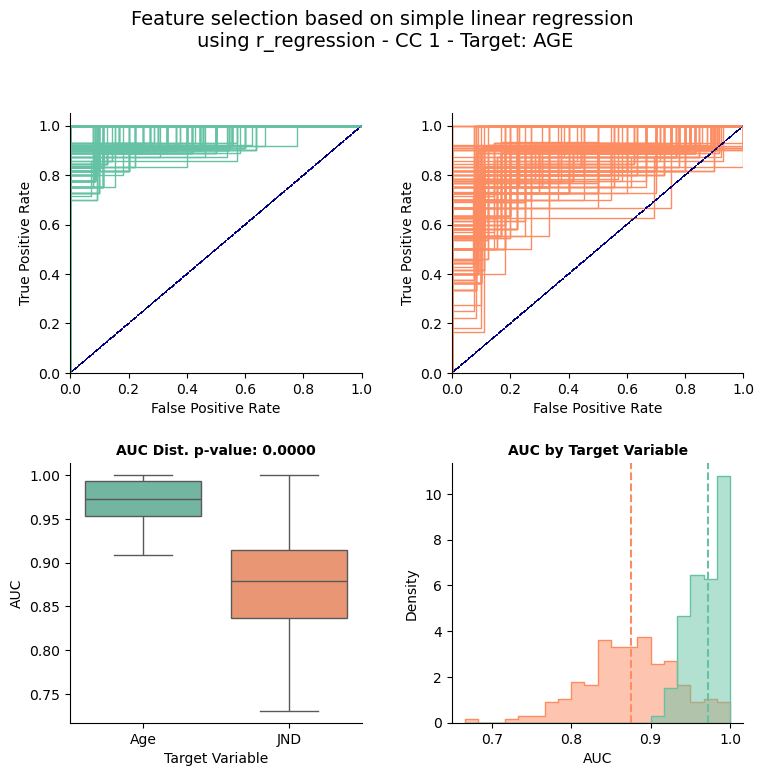

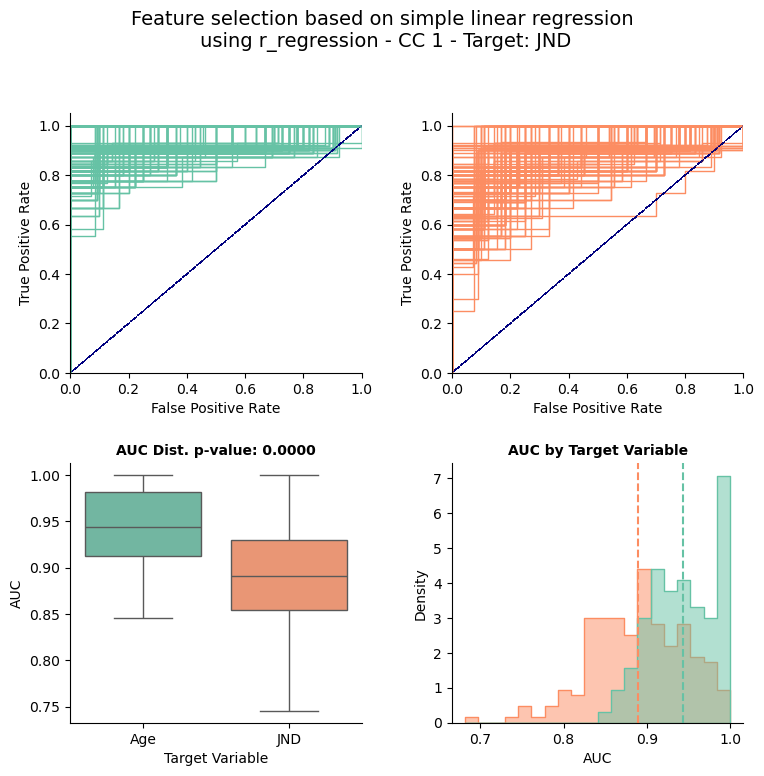

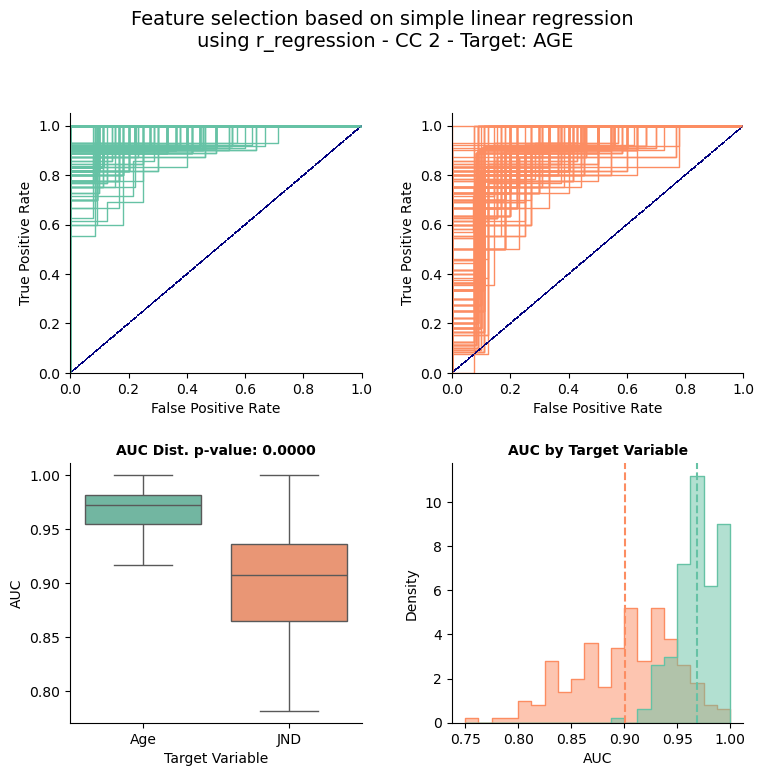

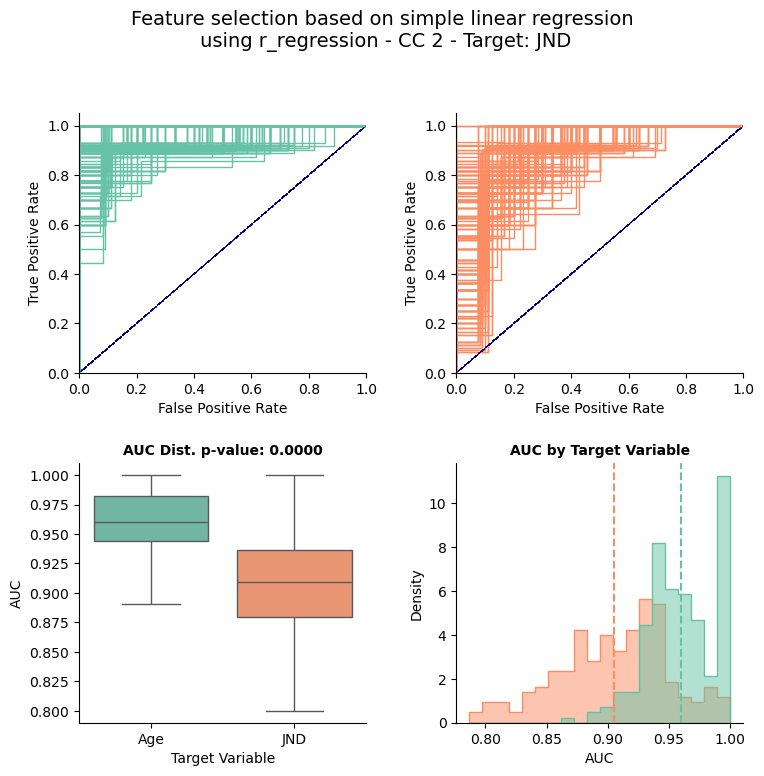

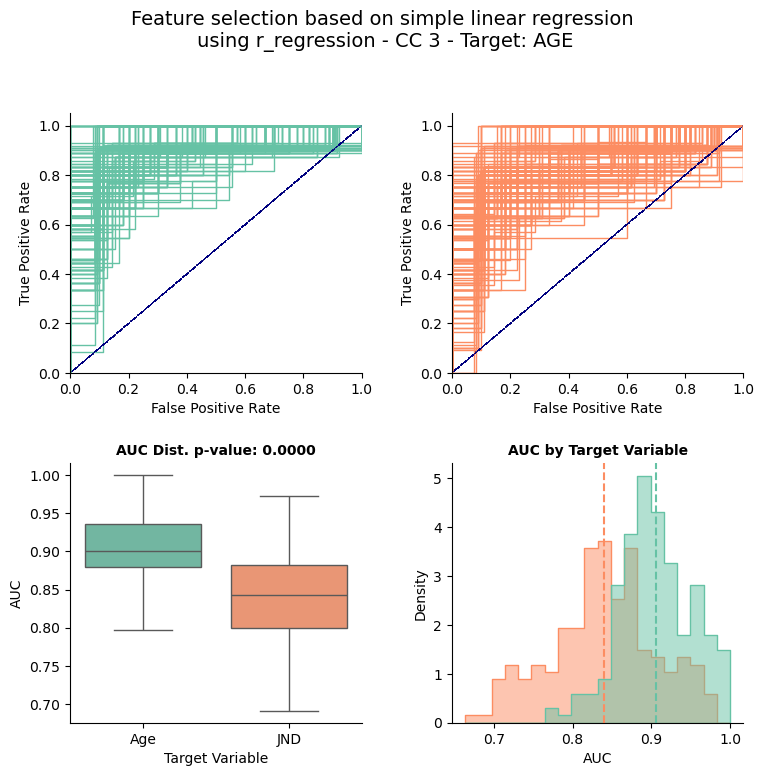

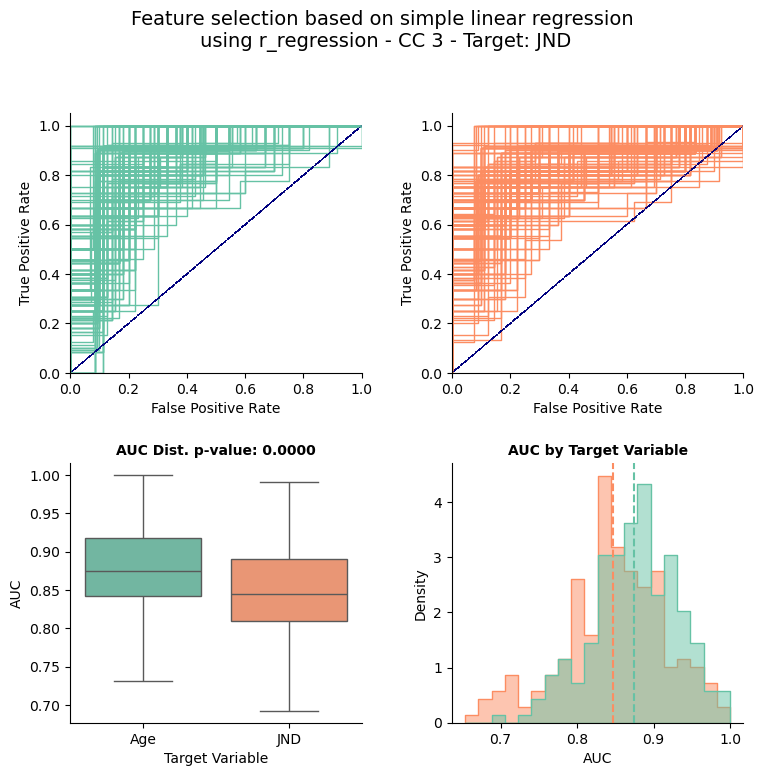

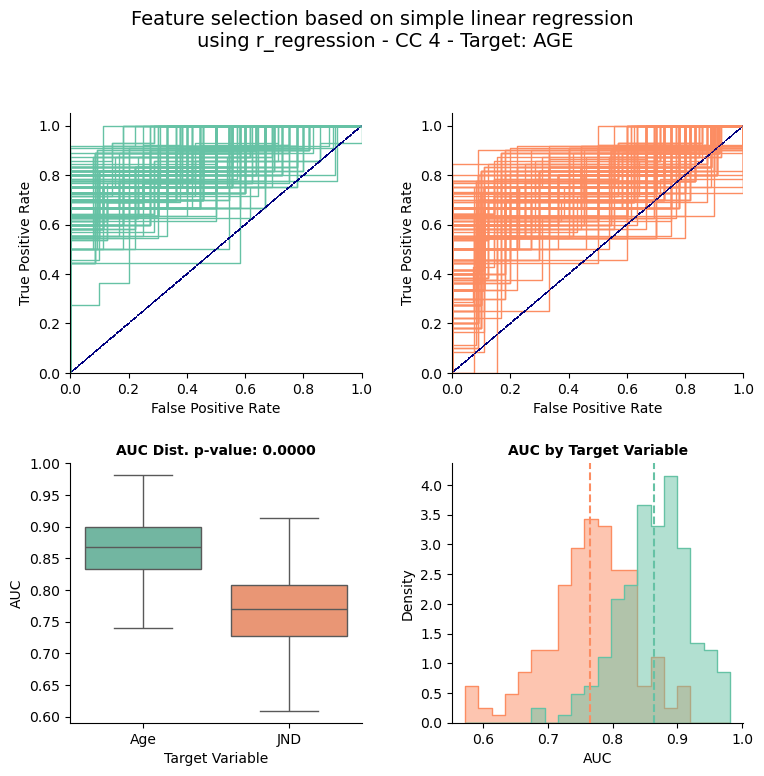

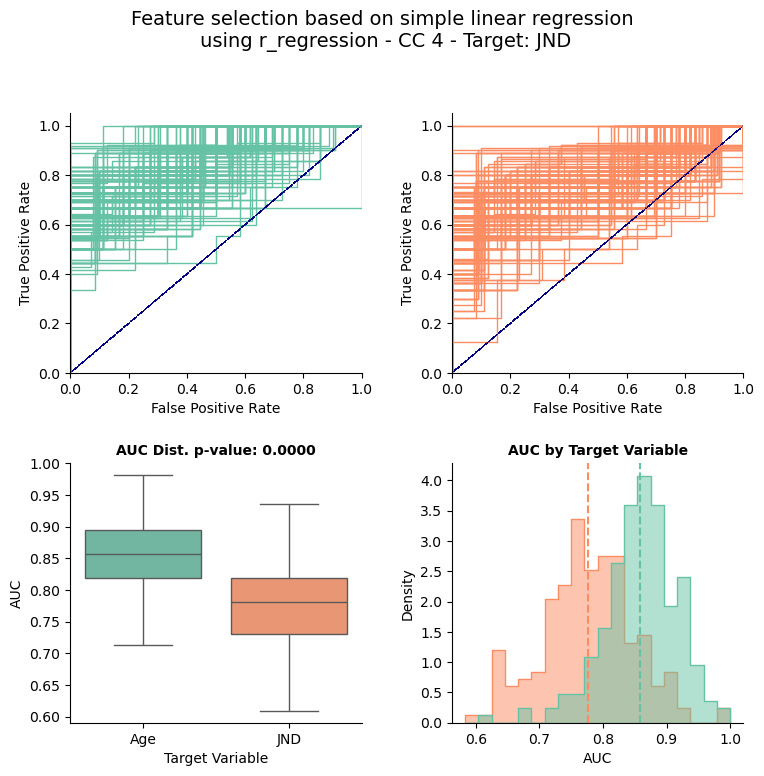

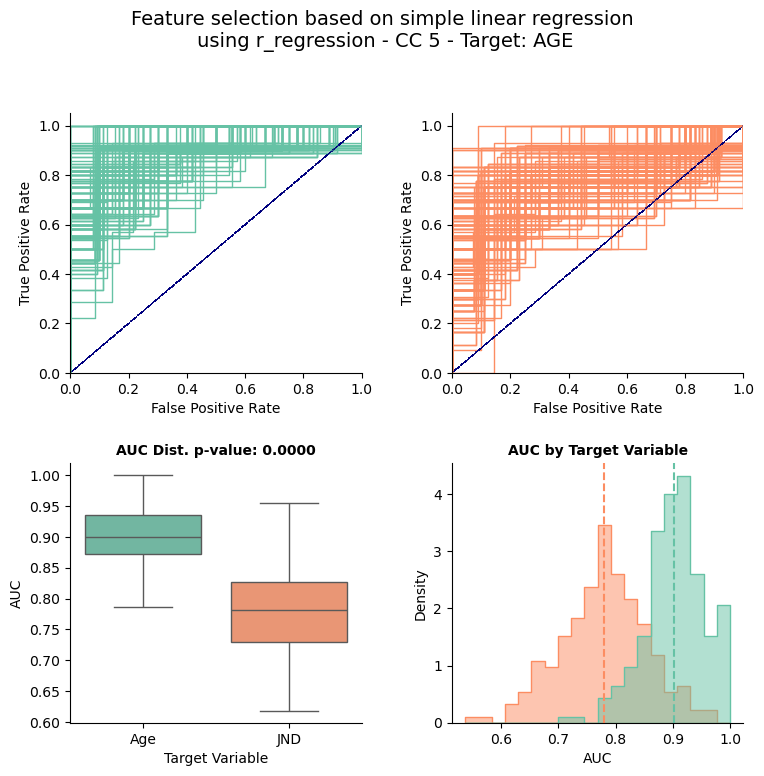

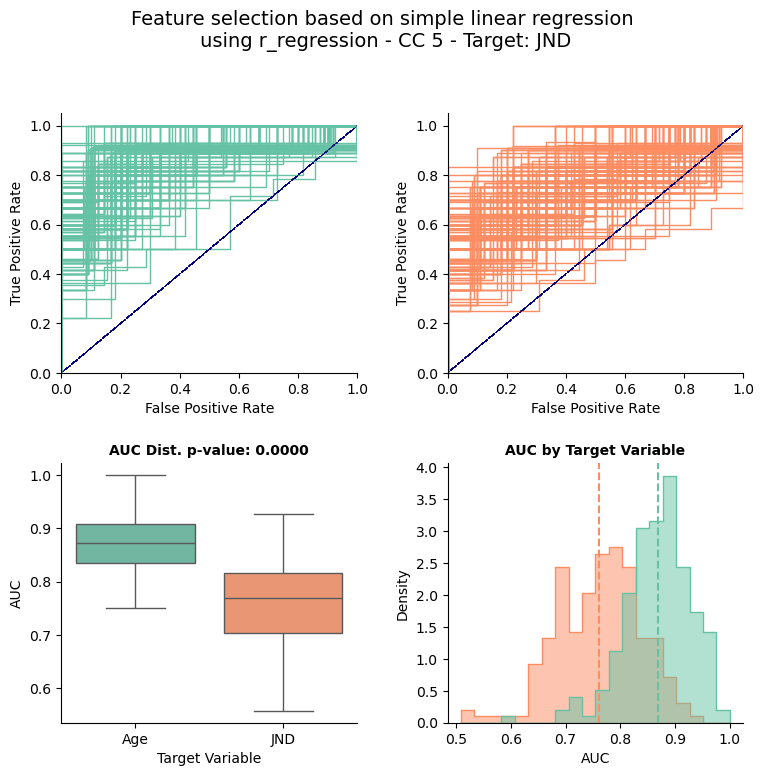

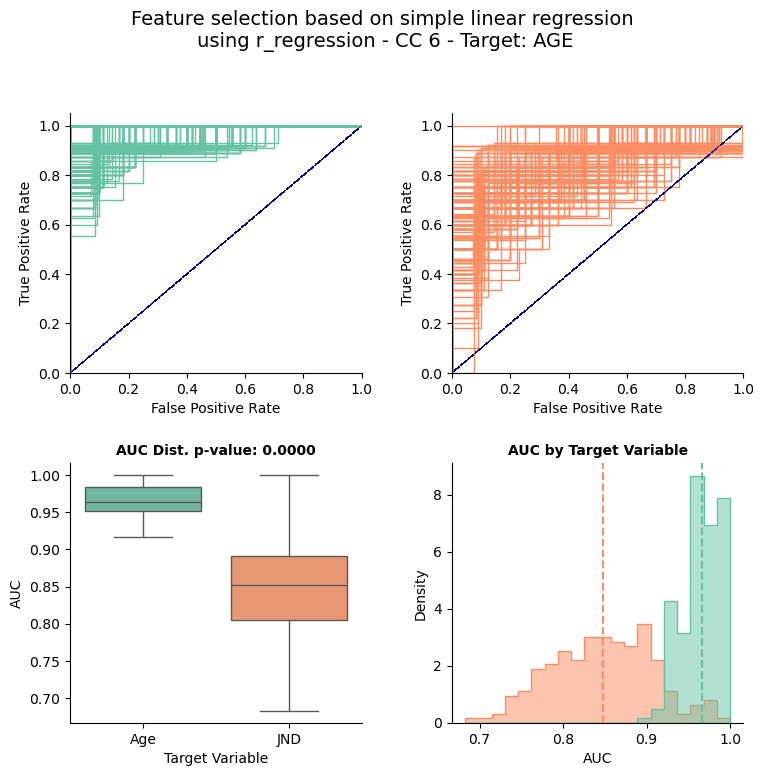

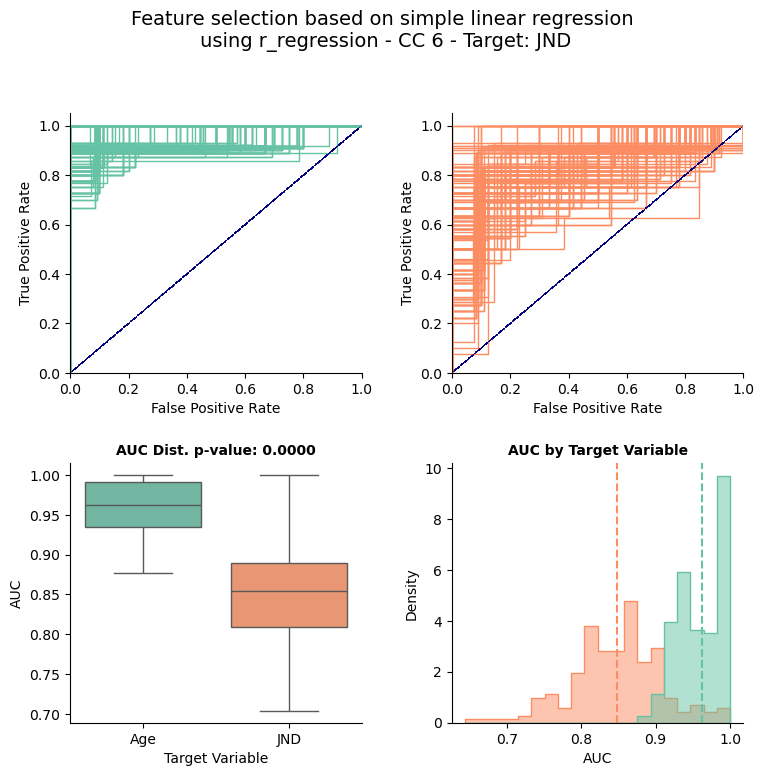

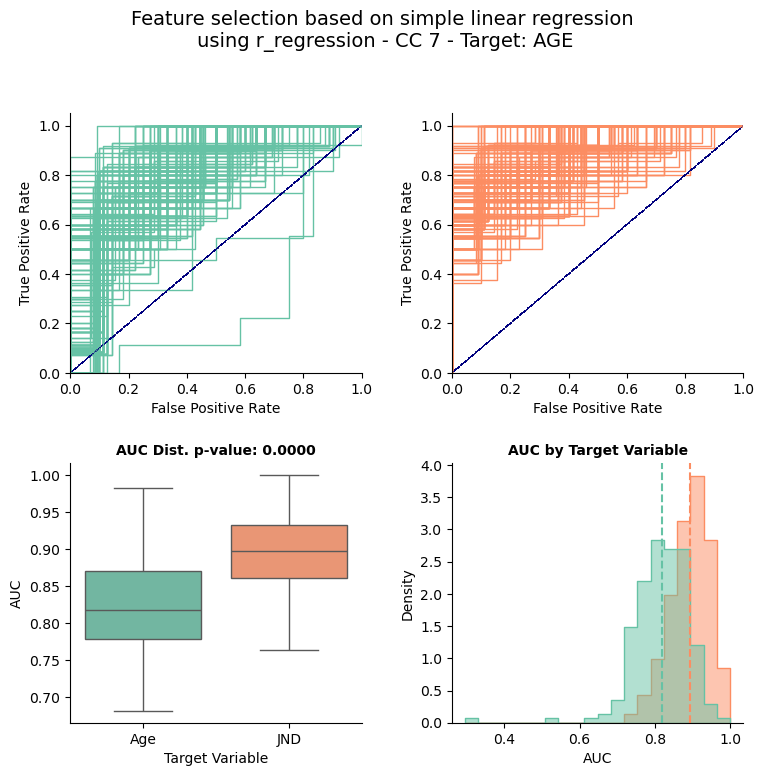

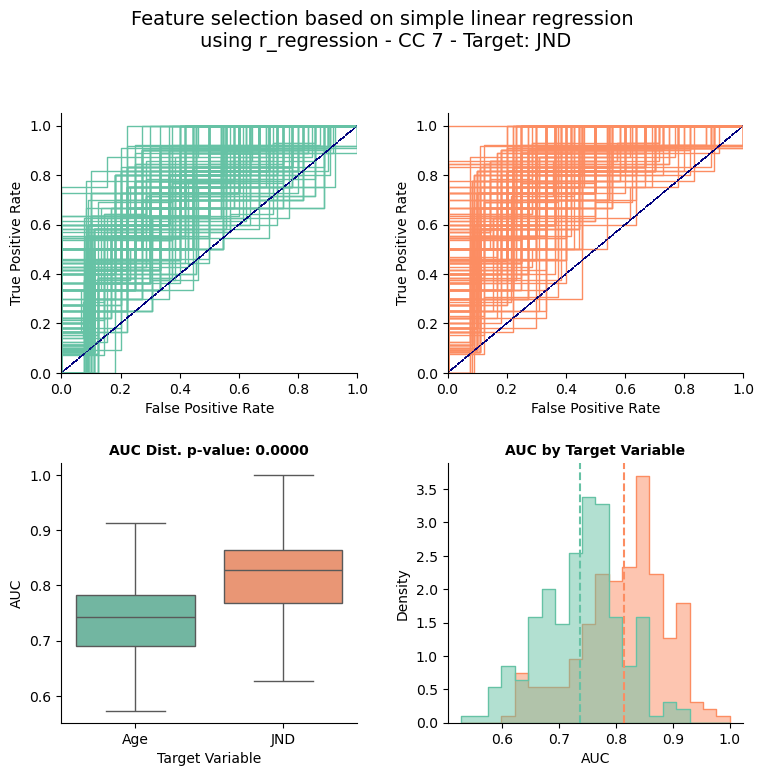

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score




colors = sns.color_palette('Set2')
first_color = colors[0]
second_color = colors[1]


for cc in range(1,8):
    print(f'CC {cc} - ROC Curve Analysis\n')


    for j,bestfeat_tgt in enumerate(['AGE','JND']):

        if bestfeat_tgt=='AGE':
            X=DTI_AGE[DTI_AGE.columns[10*(cc-1):10*(cc-1)+10]]
        elif bestfeat_tgt=='JND':
            X=DTI_JND[DTI_JND.columns[10*(cc-1):10*(cc-1)+10]]


        fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8,8))
        print(' ')
        print(' ROC Curve Analysis')

    

        fig.suptitle(f'Feature selection based on simple linear regression\n using r_regression - CC {cc} - Target: {bestfeat_tgt}\n', fontsize=14)


        target_var=  ['Age', 'JND']
        roc_auc_all = [[] for _ in target_var]

        for i, target in enumerate(target_var):
            if target == 'Age':
                y=age_grouped

            elif target == 'JND':
                y=jnd_grouped

            for seed in range(200):
                # Diviser les données en ensembles d'entraînement et de test
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)

                # Entraîner un modèle de régression logistique
                model = LogisticRegression()
                model.fit(X_train, y_train)

                # Prédire les probabilités
                y_scores = model.predict_proba(X_test)[:, 1]

                # Calculer les taux de vrais positifs et de faux positifs
                fpr, tpr, thresholds = roc_curve(y_test, y_scores)

                # Calculer l'aire sous la courbe ROC (AUC)
                roc_auc = auc(fpr, tpr)

                # Tracer la courbe ROC
                axs[0,i].plot(fpr, tpr, color=colors[i], lw=1)
                axs[0,i].plot([0, 1], [0, 1], color='navy', lw=0.5, linestyle=':')
                axs[0,i].set_xlim([0.0, 1.0])
                axs[0,i].set_ylim([0.0, 1.05])
                axs[0,i].set_xlabel('False Positive Rate')
                axs[0,i].set_ylabel('True Positive Rate')
                axs[0,i].spines['top'].set_visible(False)
                axs[0,i].spines['right'].set_visible(False)

                # Calculer l'AUC
                roc_auc = roc_auc_score(y_test, y_scores)
                roc_auc_all[i].append(roc_auc)
                # print(f'AUC: {roc_auc:.2f}')

        t,pvalue=t_test_ind(roc_auc_all[0], roc_auc_all[1])
        print(f'Mean AUC for Age: {np.mean(roc_auc_all[0]):.4f} ± {np.std(roc_auc_all[0]):.4f}')
        print(f'Mean AUC for JND: {np.mean(roc_auc_all[1]):.4f} ± {np.std(roc_auc_all[1]):.4f}')
        print(f'P-value from independent t-test: {pvalue:.4f}')

        df=pd.DataFrame({'AUC': roc_auc_all[0] + roc_auc_all[1], 'Target': ['Age']*len(roc_auc_all[0]) + ['JND']*len(roc_auc_all[1])})

        sns.boxplot(x='Target', y='AUC', data=df, ax=axs[1,0], palette='Set2',showfliers=False)
        axs[1,0].set_title(f'AUC Dist. p-value: {pvalue:.4f}', fontsize=10,fontweight='bold')
        axs[1,0].set_xlabel('Target Variable')
        axs[1,0].set_ylabel('AUC')
        axs[1,0].spines['top'].set_visible(False)
        axs[1,0].spines['right'].set_visible(False)   
        t,pvalue=t_test_ind(roc_auc_all[0], roc_auc_all[1])

        sns.histplot(data=df, x='AUC', hue='Target', element='step', stat='density', common_norm=True, ax=axs[1,1], palette='Set2', alpha=0.5,legend=False,bins=20)
        axs[1,1].set_xlabel('AUC')
        axs[1,1].set_title('AUC by Target Variable', fontsize=10,fontweight='bold')
        axs[1,1].spines['top'].set_visible(False)
        axs[1,1].spines['right'].set_visible(False)
        axs[1,1].axvline(x=np.mean(roc_auc_all[0]), color=first_color, linestyle='--', label='Mean AUC Age')
        axs[1,1].axvline(x=np.mean(roc_auc_all[1]), color=second_color, linestyle='--', label='Mean AUC JND')
        # axs[1,1].set_xlim(0.7, 1.0)

        plt.tight_layout(pad=2.0)

        

 
 ROC Curve Analysis

Mean AUC for Age: 0.5140 ± 0.1327
Mean AUC for JND: 0.5106 ± 0.1203
P-value from independent t-test: 0.7879
 
 ROC Curve Analysis

Mean AUC for Age: 0.4954 ± 0.1314
Mean AUC for JND: 0.4920 ± 0.1368
P-value from independent t-test: 0.8032


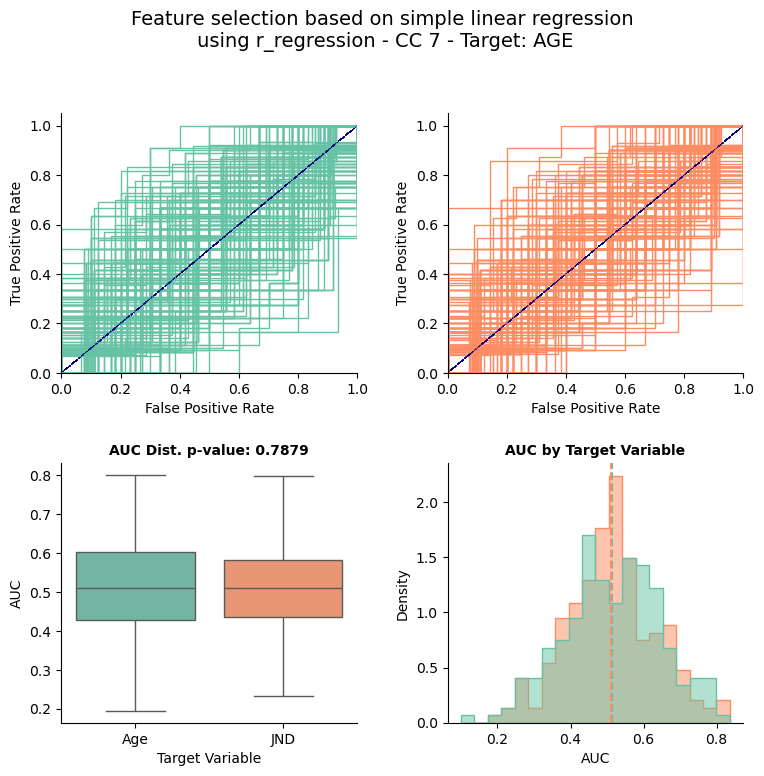

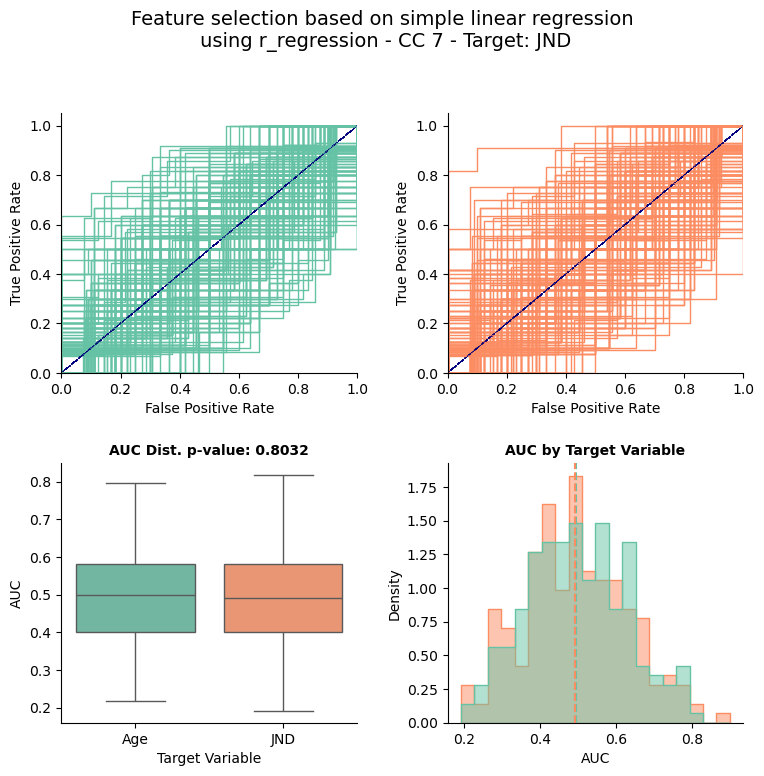

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score

colors = sns.color_palette('Set2')
first_color = colors[0]
second_color = colors[1]



cc=7

for j,bestfeat_tgt in enumerate(['AGE','JND']):

    if bestfeat_tgt=='AGE':
        X=DTI_AGE[DTI_AGE.columns[10*(cc-1):10*(cc-1)+10]]
    elif bestfeat_tgt=='JND':
        X=DTI_JND[DTI_JND.columns[10*(cc-1):10*(cc-1)+10]]


    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8,8))
    print(' ')
    print(' ROC Curve Analysis\n')

   

    fig.suptitle(f'Feature selection based on simple linear regression\n using r_regression - CC {cc} - Target: {bestfeat_tgt}\n', fontsize=14)


    target_var=  ['Age', 'JND']
    roc_auc_all = [[] for _ in target_var]

    for i, target in enumerate(target_var):
        if target == 'Age':
            y=age_grouped

        elif target == 'JND':
            y=jnd_grouped

        for seed in range(200):
            # Diviser les données en ensembles d'entraînement et de test
            y_randomized = np.random.permutation(y)

            X_train, X_test, y_train, y_test = train_test_split(X, y_randomized, test_size=0.5, random_state=seed)

            # Entraîner un modèle de régression logistique
            model = LogisticRegression()
            model.fit(X_train, y_train)

            # Prédire les probabilités
            y_scores = model.predict_proba(X_test)[:, 1]

            # Calculer les taux de vrais positifs et de faux positifs
            fpr, tpr, thresholds = roc_curve(y_test, y_scores)

            # Calculer l'aire sous la courbe ROC (AUC)
            roc_auc = auc(fpr, tpr)

            # Tracer la courbe ROC
            axs[0,i].plot(fpr, tpr, color=colors[i], lw=1)
            axs[0,i].plot([0, 1], [0, 1], color='navy', lw=0.5, linestyle=':')
            axs[0,i].set_xlim([0.0, 1.0])
            axs[0,i].set_ylim([0.0, 1.05])
            axs[0,i].set_xlabel('False Positive Rate')
            axs[0,i].set_ylabel('True Positive Rate')
            axs[0,i].spines['top'].set_visible(False)
            axs[0,i].spines['right'].set_visible(False)

            # Calculer l'AUC
            roc_auc = roc_auc_score(y_test, y_scores)
            roc_auc_all[i].append(roc_auc)
            # print(f'AUC: {roc_auc:.2f}')

    t,pvalue=t_test_ind(roc_auc_all[0], roc_auc_all[1])
    print(f'Mean AUC for Age: {np.mean(roc_auc_all[0]):.4f} ± {np.std(roc_auc_all[0]):.4f}')
    print(f'Mean AUC for JND: {np.mean(roc_auc_all[1]):.4f} ± {np.std(roc_auc_all[1]):.4f}')
    print(f'P-value from independent t-test: {pvalue:.4f}')

    df=pd.DataFrame({'AUC': roc_auc_all[0] + roc_auc_all[1], 'Target': ['Age']*len(roc_auc_all[0]) + ['JND']*len(roc_auc_all[1])})

    sns.boxplot(x='Target', y='AUC', data=df, ax=axs[1,0], palette='Set2',showfliers=False)
    axs[1,0].set_title(f'AUC Dist. p-value: {pvalue:.4f}', fontsize=10,fontweight='bold')
    axs[1,0].set_xlabel('Target Variable')
    axs[1,0].set_ylabel('AUC')
    axs[1,0].spines['top'].set_visible(False)
    axs[1,0].spines['right'].set_visible(False)   
    t,pvalue=t_test_ind(roc_auc_all[0], roc_auc_all[1])

    sns.histplot(data=df, x='AUC', hue='Target', element='step', stat='density', common_norm=True, ax=axs[1,1], palette='Set2', alpha=0.5,legend=False,bins=20)
    axs[1,1].set_xlabel('AUC')
    axs[1,1].set_title('AUC by Target Variable', fontsize=10,fontweight='bold')
    axs[1,1].spines['top'].set_visible(False)
    axs[1,1].spines['right'].set_visible(False)
    axs[1,1].axvline(x=np.mean(roc_auc_all[0]), color=first_color, linestyle='--', label='Mean AUC Age')
    axs[1,1].axvline(x=np.mean(roc_auc_all[1]), color=second_color, linestyle='--', label='Mean AUC JND')
    # axs[1,1].set_xlim(0.5, 1.0)

    plt.tight_layout(pad=2.0)

    

In [57]:
DTI_JND


,CC1_76,CC1_75,CC1_77,CC1_84,CC1_74,CC1_85,CC1_83,CC1_86,CC1_82,CC1_78,...,CC7_41,CC7_42,CC7_53,CC7_40,CC7_38,CC7_43,CC7_54,CC7_37,CC7_39,CC7_52
0,0.114795,0.174202,0.184190,0.163057,0.328016,0.349733,0.215605,0.580859,0.193845,0.198862,...,-1.714277,-1.294020,-0.918264,-2.005382,-2.100162,-1.089064,-1.111819,-2.073735,-2.101420,-0.902078
1,0.518713,0.774781,0.376193,0.893429,0.791558,0.934463,0.654611,1.011833,0.393569,0.221680,...,0.202943,0.358756,-0.271905,0.063093,-0.723384,0.020469,-0.310165,-0.887797,-0.384631,-0.321083
2,0.450810,0.597188,0.438739,1.058013,0.519472,1.148760,1.024891,1.138469,1.041839,0.517428,...,-0.246049,-0.510282,-0.117186,0.347142,0.560809,0.018561,-0.448470,0.698073,0.594707,0.374144
3,-0.161989,-0.103607,-0.214222,0.044867,-0.035578,0.137969,-0.021069,0.289357,-0.115618,-0.166335,...,-1.090429,-0.793458,0.675194,-0.973297,-0.226953,-0.247616,-0.100639,-0.196186,-0.578869,0.856489
4,1.357095,1.413808,1.326143,1.676764,1.445326,1.577227,1.751379,1.555624,1.700549,1.350875,...,1.104727,1.456291,2.125678,1.029556,1.566164,1.974666,1.614007,1.491592,1.422518,2.261473
5,-0.211185,-0.353987,-0.118914,0.055851,-0.388908,-0.027708,0.122419,-0.070924,0.180131,0.100944,...,-1.770921,-1.939664,-0.679933,-1.413700,-1.178057,-1.699291,-1.092271,-0.906764,-1.182985,-0.528353
6,-0.678191,-0.602441,-0.749892,-0.648226,-0.471060,-0.629047,-0.674666,-0.540907,-0.748983,-0.782576,...,-0.051153,0.202187,0.673557,-0.014834,-0.189202,0.652806,-0.341597,-0.244917,0.051448,1.263736
7,-0.264150,-0.233904,-0.291380,0.414850,-0.132945,0.637407,0.243214,0.687217,0.058526,-0.343729,...,-0.016712,-0.078367,-1.443472,0.199800,-0.112685,-0.136072,-0.850846,-0.545371,0.364084,-1.435337
8,0.092767,0.140510,0.068896,0.033721,0.356633,-0.166660,0.040714,-0.289214,0.140354,0.035914,...,0.173842,0.550009,0.433851,0.085338,0.306646,0.620304,0.242929,0.364657,0.119818,0.577444
9,1.026489,1.070551,1.026496,0.474684,1.101102,0.482114,0.509629,0.402776,0.703125,1.013243,...,1.392422,1.111672,0.990071,1.603749,1.516785,0.889559,1.364389,1.278865,1.597754,0.800271


In [71]:
data_adjusted.values

array([-1.91952388, -0.57274518, -0.19966646, -0.73833235,  1.2161653 ,
       -0.76402722,  0.79875098,  0.00797814, -0.12327219,  0.78379772,
        0.64731922,  0.70642118,  0.5880217 ,  0.06601823, -0.59552245,
        1.50916652, -0.07532264,  0.3228216 , -0.30214498,  0.57402789,
       -0.19583515,  0.24478242, -0.66592139,  0.72035747, -0.16034487,
       -0.69903109, -0.96313667, -1.73111129,  1.14763192, -0.85238431,
        0.61379593, -0.57487469,  1.01895869,  1.27401888, -1.36803867,
       -0.29091932, -0.61778335,  0.60678881,  0.42638612,  0.57559279,
       -0.48177695,  0.04291362])

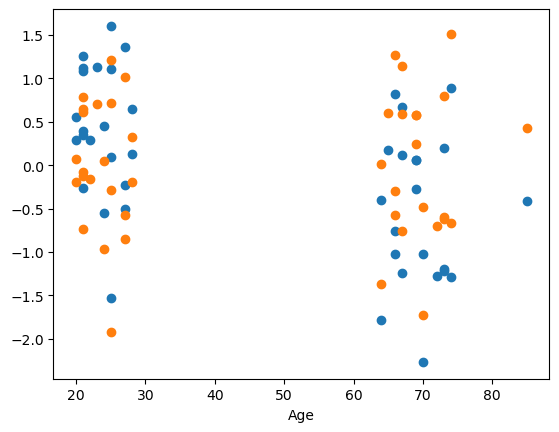

In [ ]:
data = DTI_JND[DTI_JND.columns[60:70].tolist()].mean(axis=1)

data_adjusted = data.copy()


seg=25
cc=6

# Ajouter une constante à la variable indépendante
X = sm.add_constant(age)
y = data

# Créer le modèle de régression multiple
model = sm.OLS(y, X)

# Ajuster le modèle
results = model.fit()   

# Calculer les résidus
residuals = results.resid

# Mettre à jour les données DTI avec les résidus
data_adjusted = residuals

plt.plot(age, data, 'o', label='DTI Original')
plt.plot(age, data_adjusted, 'o', label='DTI Adjusted')
plt.xlabel('Age')
plt.show()




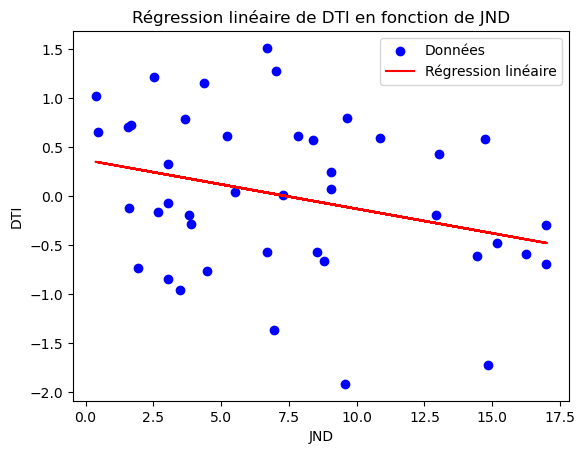

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     4.041
Date:              mer., 18 mars 2026   Prob (F-statistic):             0.0512
Time:                        10:17:29   Log-Likelihood:                -48.080
No. Observations:                  42   AIC:                             100.2
Df Residuals:                      40   BIC:                             103.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3657      0.218      1.677      0.1

In [83]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt



# Ajouter une constante à la variable indépendante
X = sm.add_constant(jnd)
y = data_adjusted.values

# Créer le modèle de régression linéaire
model = sm.OLS(y, X)

# Ajuster le modèle
results = model.fit()

# Extraire les coefficients
slope = results.params[1]
intercept = results.params[0]

# Créer une ligne de régression
regression_line = slope * jnd + intercept

# Tracer les points de données
plt.scatter(jnd, data_adjusted, color='blue', label='Données')

# Tracer la ligne de régression
plt.plot(jnd, regression_line, color='red', label='Régression linéaire')

# Ajouter des labels et un titre
plt.xlabel('JND')
plt.ylabel('DTI')
plt.title('Régression linéaire de DTI en fonction de JND')
plt.legend()

# Afficher le graphique
plt.show()
print(results.summary())
